In [1]:
import os
import sys
import numpy as np
import random
import time
import pickle
from tqdm import trange
import math

#model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from deepxde.nn import activations, initializers
import torch.autograd as autograd

# Evaluation
from scipy.stats import pearsonr, spearmanr

# Module
sys.path.append('/root/') # absolute path to root project folder
import xarray as xr
import Baseline.mre_pinn
from Baseline.mre_pinn.data.dataset import MREExample
from eval_utils import *

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


# FEM Box dataset

In [2]:
fem_box_freqs = [50, 60, 70, 80, 90, 100]
fem_box_results_path = '../Results/fem_box/'
fem_box_img_path = '../Results/fem_box_images/'
space = 0.001
coords_shape = [80, 100, 10]

In [3]:
dataroot = '../Data/BIOQIC/fem_box/'
fem_box_dict={}
for f in fem_box_freqs:
    try:
        example = MREExample.load_xarrays(dataroot, f)
        x = example.wave.field.points().reshape(*coords_shape, -1)#*10
        u = example.wave.field.values().reshape(*coords_shape, 3).real#*1000
        mu = example.mre.field.values().reshape(*coords_shape).real
        fem_box_dict[int(f)] = {'x':x, 'u': u, 'mu': mu, 'example': example}
    except:
        print('error open {}'.format(f))

Loading ../Data/BIOQIC/fem_box/50/wave.nc
Loading ../Data/BIOQIC/fem_box/50/mre.nc
Loading ../Data/BIOQIC/fem_box/50/mre_mask.nc
Loading ../Data/BIOQIC/fem_box/60/wave.nc
Loading ../Data/BIOQIC/fem_box/60/mre.nc
Loading ../Data/BIOQIC/fem_box/60/mre_mask.nc
Loading ../Data/BIOQIC/fem_box/70/wave.nc
Loading ../Data/BIOQIC/fem_box/70/mre.nc
Loading ../Data/BIOQIC/fem_box/70/mre_mask.nc
Loading ../Data/BIOQIC/fem_box/80/wave.nc
Loading ../Data/BIOQIC/fem_box/80/mre.nc
Loading ../Data/BIOQIC/fem_box/80/mre_mask.nc
Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Loading ../Data/BIOQIC/fem_box/100/wave.nc
Loading ../Data/BIOQIC/fem_box/100/mre.nc
Loading ../Data/BIOQIC/fem_box/100/mre_mask.nc


## Experiments results

In [8]:
import colorcet as cc
import matplotlib.colors as mcolors
def brighten_and_gamma_correct_colormap(cmap, factor=1, gamma=1.5):
    colors = cmap(np.linspace(0, 1, 256))
    colors[:, :3] = np.clip(colors[:, :3] * factor, 0, 1) 
    colors[:, :3] = np.power(colors[:, :3], gamma) 
    return mcolors.ListedColormap(colors)

bright_cmap = brighten_and_gamma_correct_colormap(cc.cm['cyclic_wrkbw_10_90_c43'], factor=1.5, gamma=1)

### MREHyper

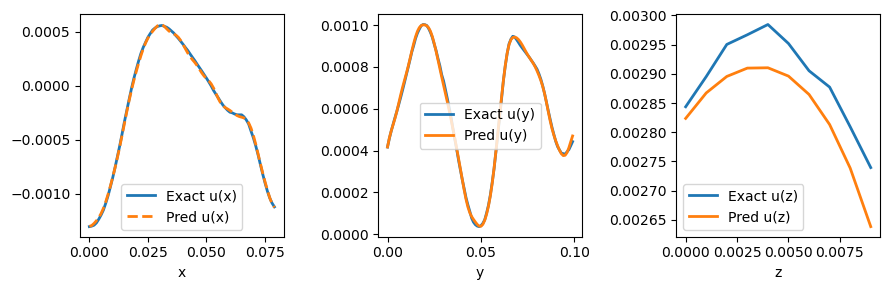

Image saved to ../Results/images/GT_50_0.0.png
Image saved to ../Results/images/MREHyper_preds_50_0.0.png
Frequency : 50
u recon relative L2 error: 0.016415251985618183
mu pearson correlation: 0.756558119793449
Region 1 CTE : 97.65179966517857 
Region 2 CTE : 53.84947335379464 
Region 3 CTE : 8.979750279017857 
Region 4 CTE : 0.2656982421875
Mean CTE error: 59.81331961495536


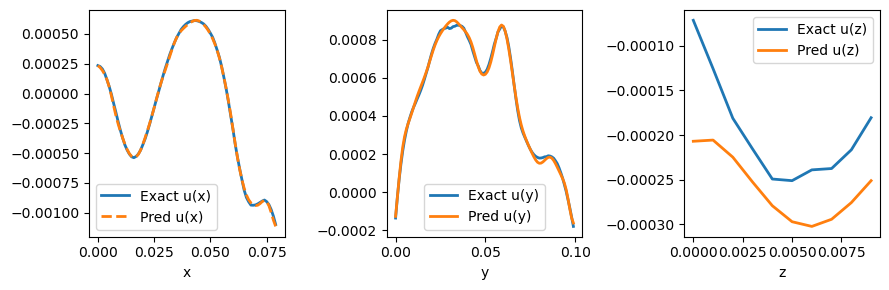

Image saved to ../Results/images/GT_60_0.0.png
Image saved to ../Results/images/MREHyper_preds_60_0.0.png
Frequency : 60
u recon relative L2 error: 0.027661511510833316
mu pearson correlation: 0.8134971824727764
Region 1 CTE : 84.92501395089286 
Region 2 CTE : 70.51417410714286 
Region 3 CTE : 45.26344168526786 
Region 4 CTE : 7.1250069754464285
Mean CTE error: 48.0430908203125


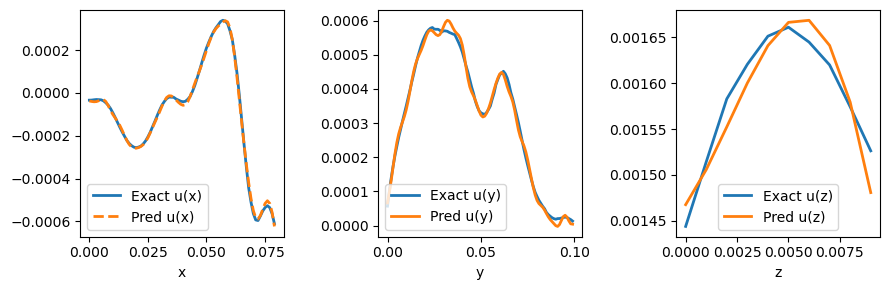

Image saved to ../Results/images/GT_70_0.0.png
Image saved to ../Results/images/MREHyper_preds_70_0.0.png
Frequency : 70
u recon relative L2 error: 0.02297456265449859
mu pearson correlation: 0.8096219106373663
Region 1 CTE : 84.88390066964286 
Region 2 CTE : 74.33929966517857 
Region 3 CTE : 26.210592215401785 
Region 4 CTE : 13.33115234375
Mean CTE error: 50.308763776506694


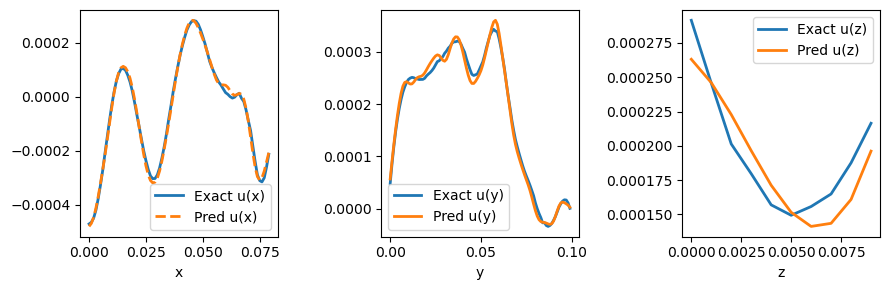

Image saved to ../Results/images/GT_80_0.0.png
Image saved to ../Results/images/MREHyper_preds_80_0.0.png
Frequency : 80
u recon relative L2 error: 0.028574644873624946
mu pearson correlation: 0.7415231415166302
Region 1 CTE : 71.28670479910714 
Region 2 CTE : 46.94877580915179 
Region 3 CTE : 10.635773577008928 
Region 4 CTE : 5.1976318359375
Mean CTE error: 66.48277849469866


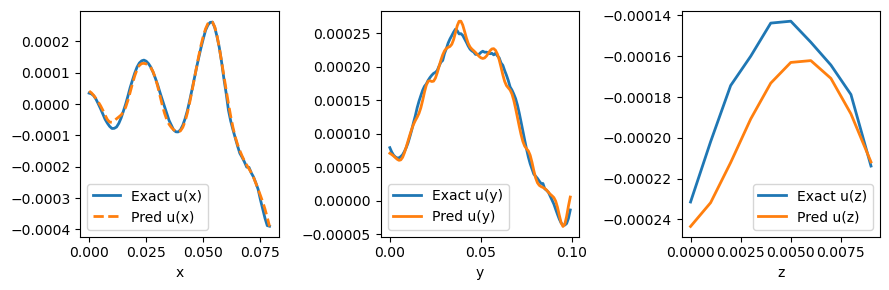

Image saved to ../Results/images/GT_90_0.0.png
Image saved to ../Results/images/MREHyper_preds_90_0.0.png
Frequency : 90
u recon relative L2 error: 0.04134859760433041
mu pearson correlation: 0.8167656329842754
Region 1 CTE : 77.67269112723214 
Region 2 CTE : 64.05754045758928 
Region 3 CTE : 46.51233258928571 
Region 4 CTE : 16.189411272321426
Mean CTE error: 48.89200613839286


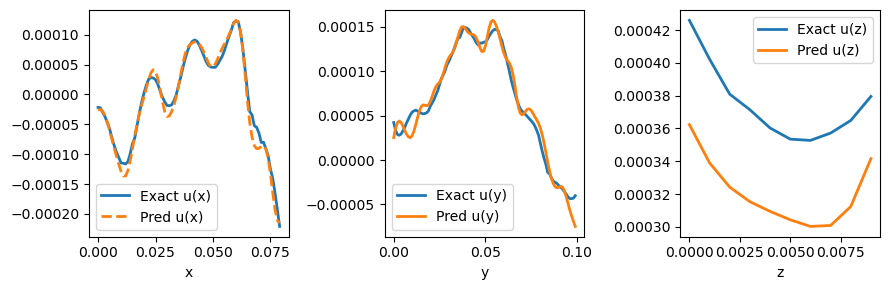

Image saved to ../Results/images/GT_100_0.0.png
Image saved to ../Results/images/MREHyper_preds_100_0.0.png
Frequency : 100
u recon relative L2 error: 0.07000710778757918
mu pearson correlation: 0.8038462358190467
Region 1 CTE : 75.61886160714286 
Region 2 CTE : 59.81979631696429 
Region 3 CTE : 40.623259626116074 
Region 4 CTE : 12.245057896205356
Mean CTE error: 52.92325613839286


In [21]:
for f in fem_box_freqs:
    data_file = fem_box_results_path+'MREHyper_preds_{}_0.0.pkl'.format(f)
    with open(data_file, 'rb') as file:
        data = pickle.load(file)
        u_pred, u, mu_pred, mu = data
        u_compare_visualization(u_pred.reshape(*coords_shape, 3).detach().cpu().numpy(), u, x, (30, 90, 5))
        z_fixed = 5
        mu_pred = mu_pred.reshape(*coords_shape).real.detach().cpu().numpy()
        #visualize_mu_slice(u[...,0], fixed_axis='z', fixed_index=z_fixed, cmap=bright_cmap , log_scale=False, vmax=0.002, vmin=-0.002, save_path=fem_box_img_path+'wave_{}.png'.format(f))
        #visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis', save_path=fem_box_img_path+'GT_{}_0.0.png'.format(f))
        visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'MREHyper_preds_{}_0.0.png'.format(f))
        rel_l2_loss = relative_l2_loss(u_pred.real.detach().cpu().numpy(), u.reshape(-1,3))
        ex = fem_box_dict[f]['example']
        region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
        print('Frequency : {}'.format(f))
        print('u recon relative L2 error: {}'.format(rel_l2_loss))
        print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
        print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
        print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### MRE-PINN

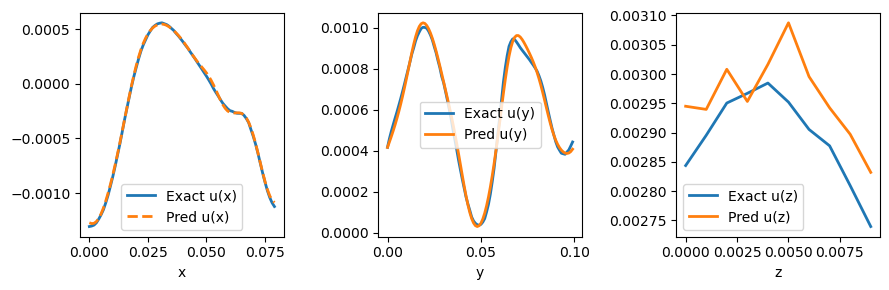

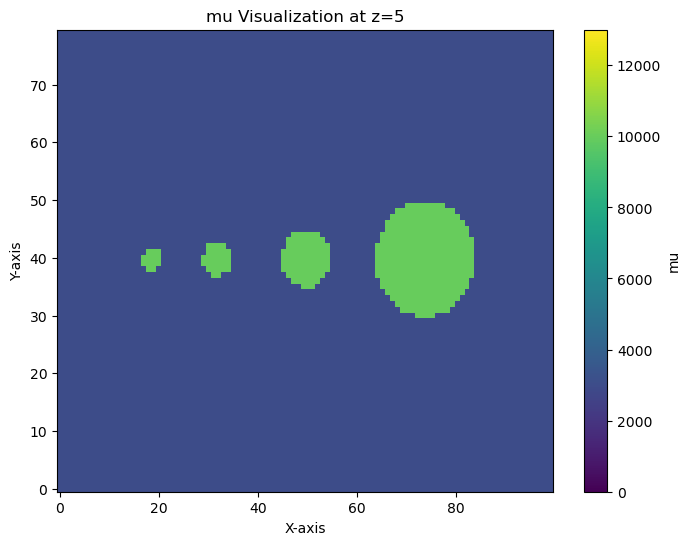

Image saved to ../Results/fem_box_images/mrepinn_preds_50_0.0.png


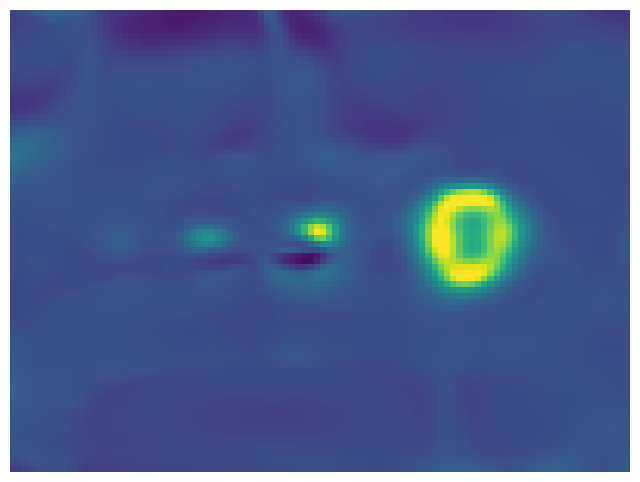

Frequency : 50
u recon relative L2 error: 0.020610342760021723
mu pearson correlation: 0.7891638912939734
Region 1 CTE : 83.37613809241887 
Region 2 CTE : 43.694334142370344 
Region 3 CTE : 30.958046681170202 
Region 4 CTE : 7.435478440694247
Mean CTE error: 58.634000660836584


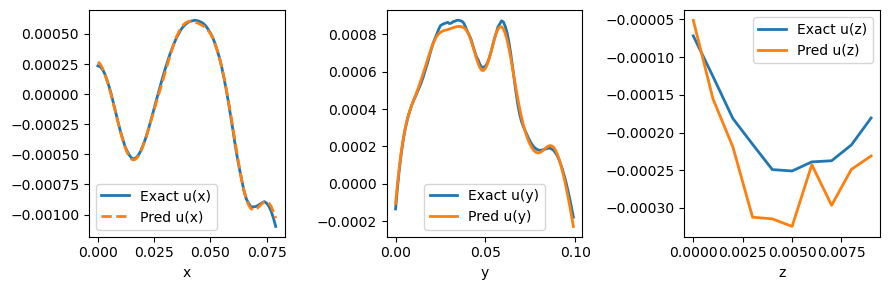

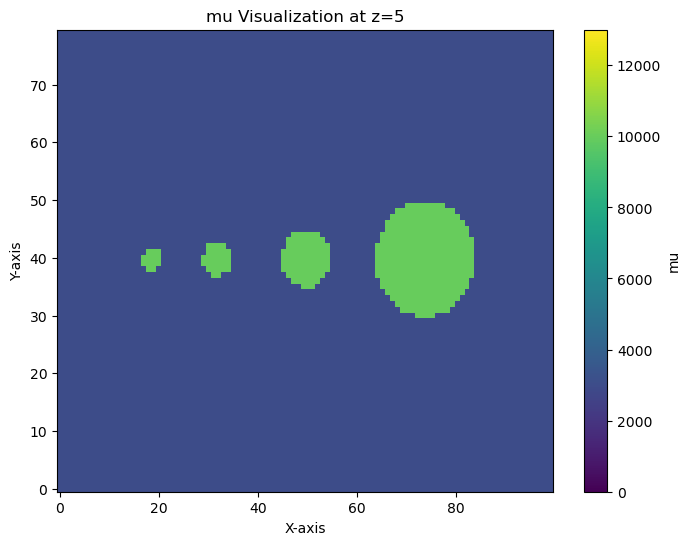

Image saved to ../Results/fem_box_images/mrepinn_preds_60_0.0.png


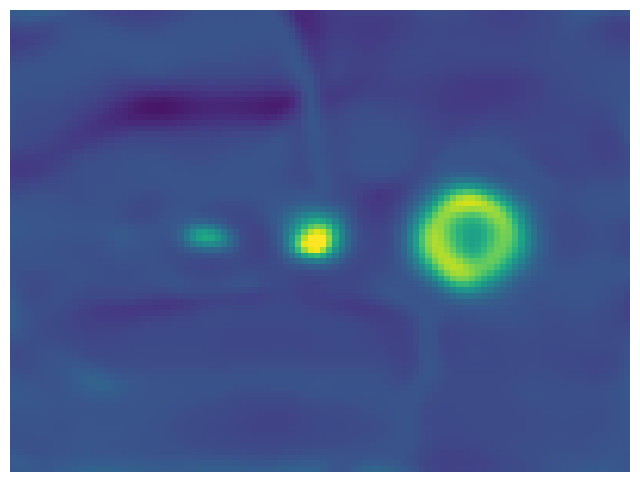

Frequency : 60
u recon relative L2 error: 0.029534228778294612
mu pearson correlation: 0.8445463896475122
Region 1 CTE : 76.67469771459417 
Region 2 CTE : 67.10763357508898 
Region 3 CTE : 39.5352828723978 
Region 4 CTE : 5.4150430502643045
Mean CTE error: 52.816835696913685


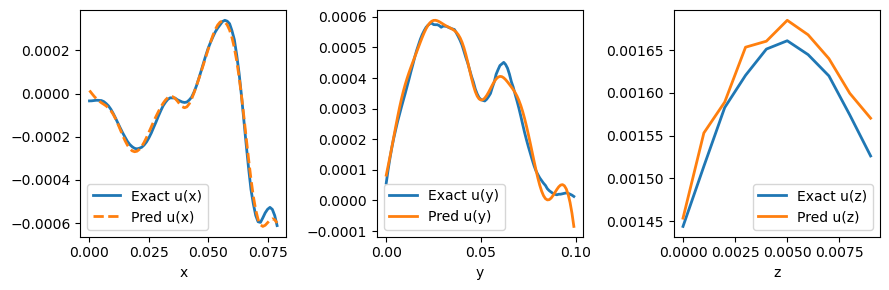

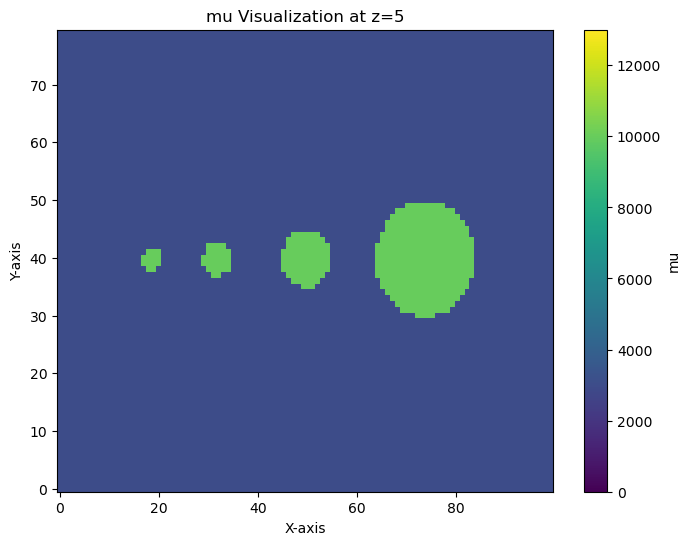

Image saved to ../Results/fem_box_images/mrepinn_preds_70_0.0.png


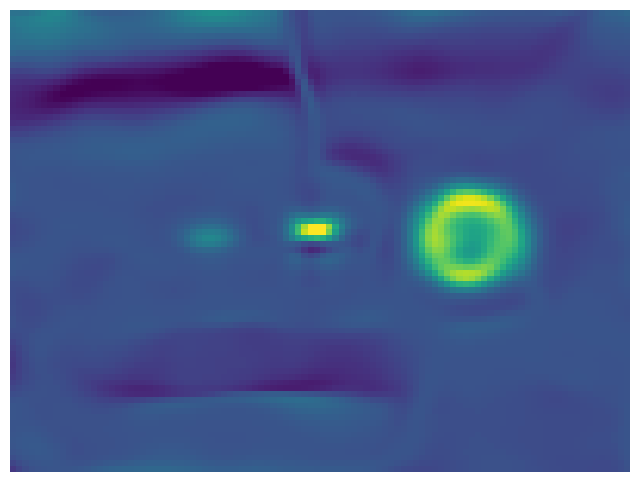

Frequency : 70
u recon relative L2 error: 0.02803675153396161
mu pearson correlation: 0.7484132240977015
Region 1 CTE : 76.41648335922737 
Region 2 CTE : 64.13366167307898 
Region 3 CTE : 27.59559011777159 
Region 4 CTE : 6.179747642546564
Mean CTE error: 56.41862930184388


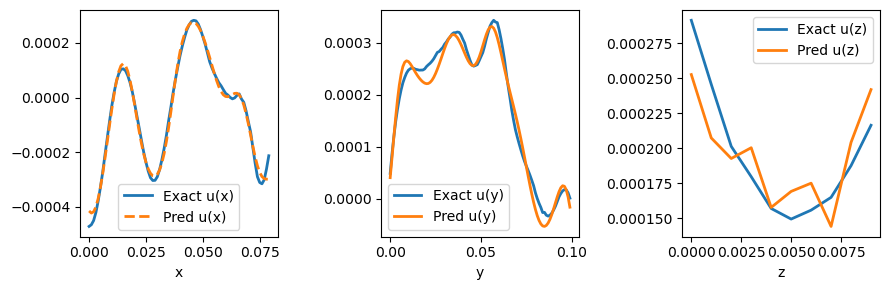

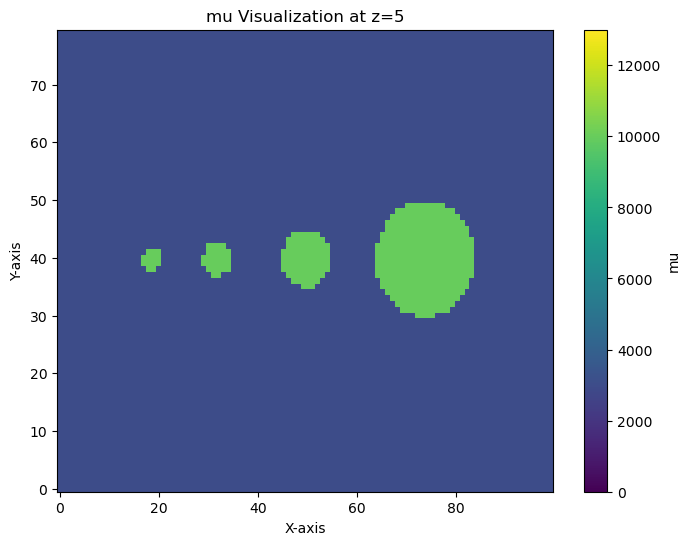

Image saved to ../Results/fem_box_images/mrepinn_preds_80_0.0.png


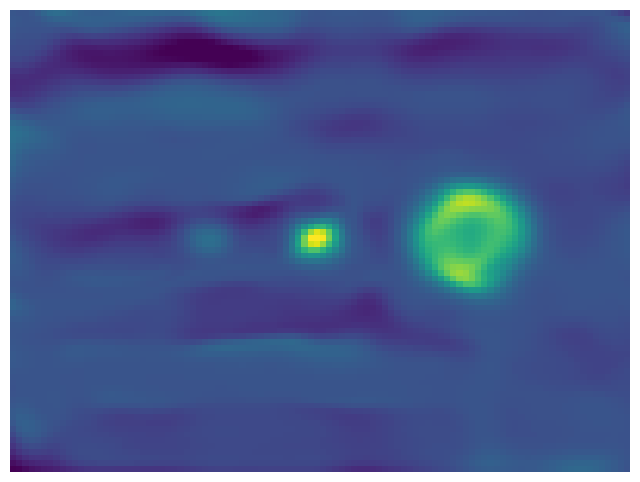

Frequency : 80
u recon relative L2 error: 0.035653018599662474
mu pearson correlation: 0.7557138512177632
Region 1 CTE : 70.3941666224379 
Region 2 CTE : 52.680032749284656 
Region 3 CTE : 17.60983003591089 
Region 4 CTE : -10.540213928163322
Mean CTE error: 67.46404613013247


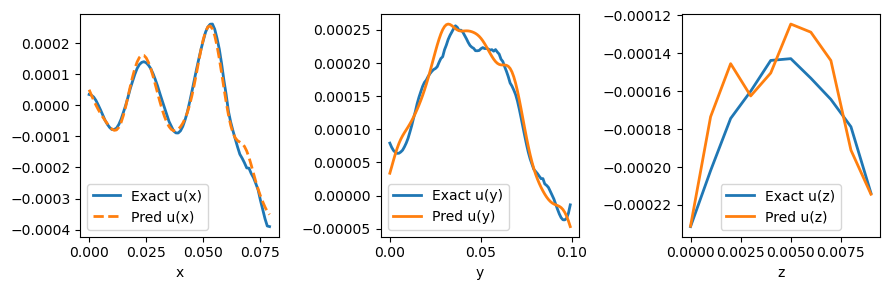

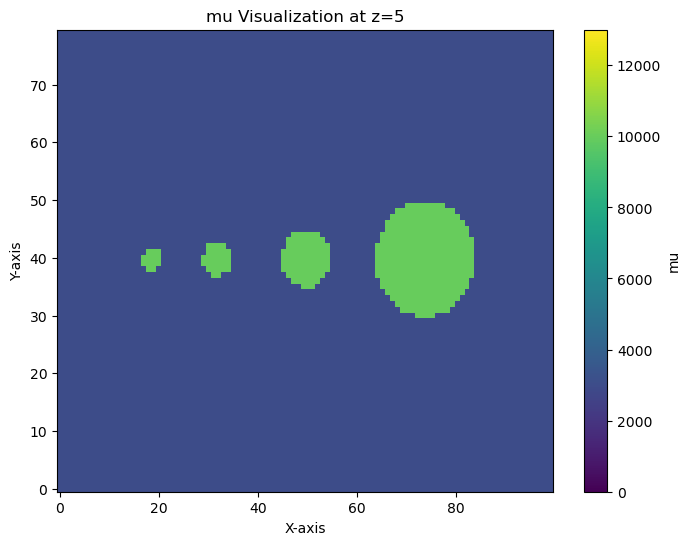

Image saved to ../Results/fem_box_images/mrepinn_preds_90_0.0.png


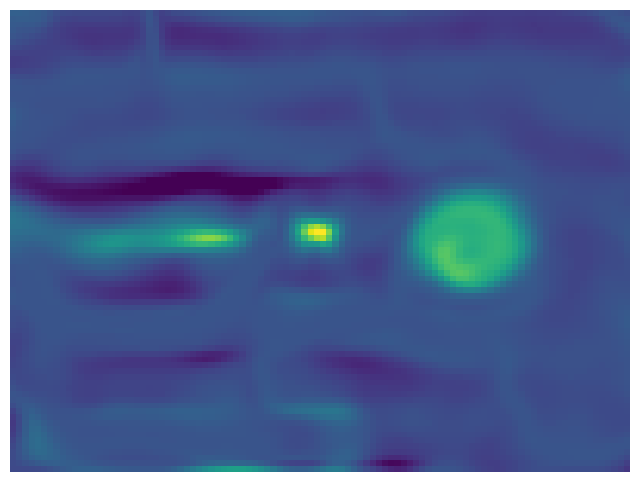

Frequency : 90
u recon relative L2 error: 0.0541392191949316
mu pearson correlation: 0.7231190680913828
Region 1 CTE : 60.04105581656059 
Region 2 CTE : 40.408605304145425 
Region 3 CTE : 62.60156534176111 
Region 4 CTE : 42.28105730855906
Mean CTE error: 48.66692905724345


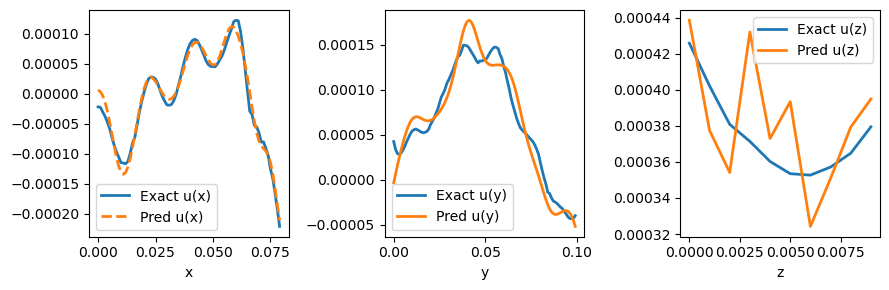

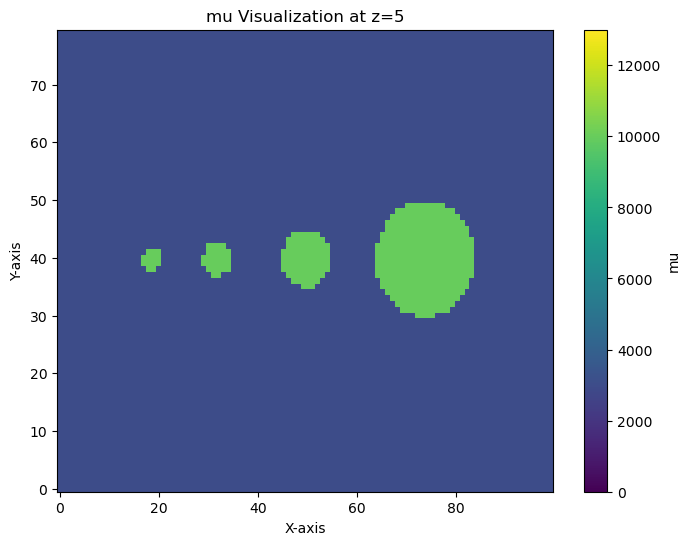

Image saved to ../Results/fem_box_images/mrepinn_preds_100_0.0.png


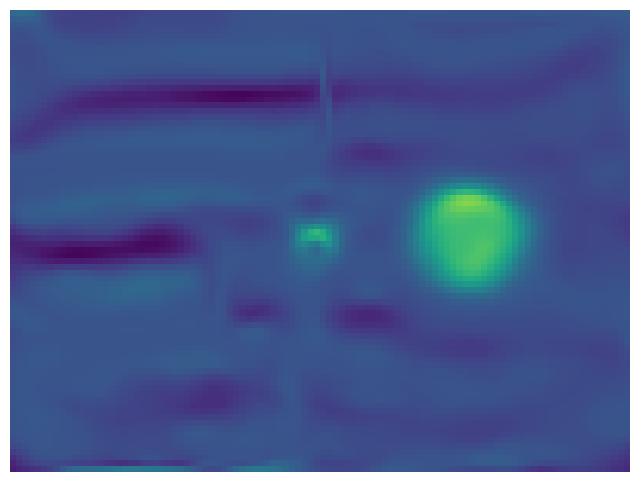

Frequency : 100
u recon relative L2 error: 0.07993904128905854
mu pearson correlation: 0.7148133589126958
Region 1 CTE : 61.0305563241358 
Region 2 CTE : 36.367930355359924 
Region 3 CTE : 1.48020380077248 
Region 4 CTE : -19.095696133796185
Mean CTE error: 80.05425141338199


In [13]:
for f in fem_box_freqs:
    data_file = fem_box_results_path+'mrepinn_preds_{}_0.0.pkl'.format(f)
    with open(data_file, 'rb') as file:
        data = pickle.load(file)
        u_pred, u, mu_pred, mu = data
        x = fem_box_dict[f]['x']
        u_compare_visualization(u_pred.reshape(*coords_shape, 3).detach().cpu().numpy(), u, x, (30, 90, 5))
        z_fixed = 5
        mu_pred = mu_pred.reshape(*coords_shape).real.detach().cpu().numpy()
        visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
        visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'mrepinn_preds_{}_0.0.png'.format(f))
        rel_l2_loss = relative_l2_loss(u_pred.real.detach().cpu().numpy(), u.reshape(-1,3))
        ex = fem_box_dict[f]['example']
        region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
        print('Frequency : {}'.format(f))
        print('u recon relative L2 error: {}'.format(rel_l2_loss))
        print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
        print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
        print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### AHI

In [6]:
for k,v in fem_box_dict.items():
    example = v['example']
    Baseline.mre_pinn.baseline.eval_ahi_baseline(example, frequency=k, despeckle=True) # if despeckle is True outliers are filtered

Evaluating direct baseline
Evaluating direct baseline
Evaluating direct baseline
Evaluating direct baseline
Evaluating direct baseline
Evaluating direct baseline


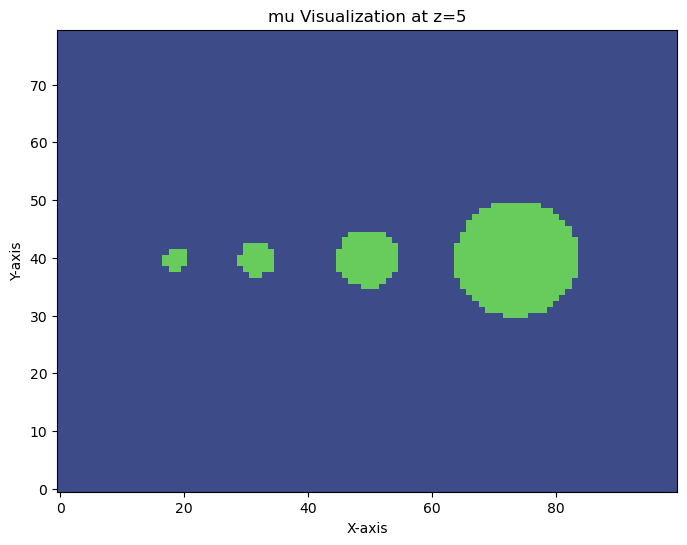

Image saved to ../Results/images/AHI_preds_50_0.0.png
Frequency : 50
mu pearson correlation: 0.6102119598657441
Region 1 CTE : 82.09889917898174 
Region 2 CTE : 98.27510157666009 
Region 3 CTE : -27.985695063072484 
Region 4 CTE : -17.057819141620563
Mean CTE error: 66.16737836226281


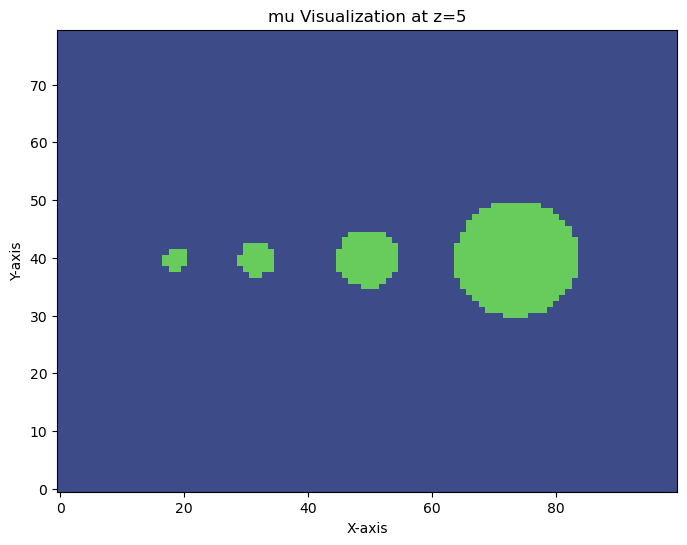

Image saved to ../Results/images/AHI_preds_60_0.0.png
Frequency : 60
mu pearson correlation: 0.5437337341041153
Region 1 CTE : 71.35900714011217 
Region 2 CTE : -18.091529537418012 
Region 3 CTE : -26.89449655614162 
Region 4 CTE : 2.625891277835782
Mean CTE error: 92.75028191890293


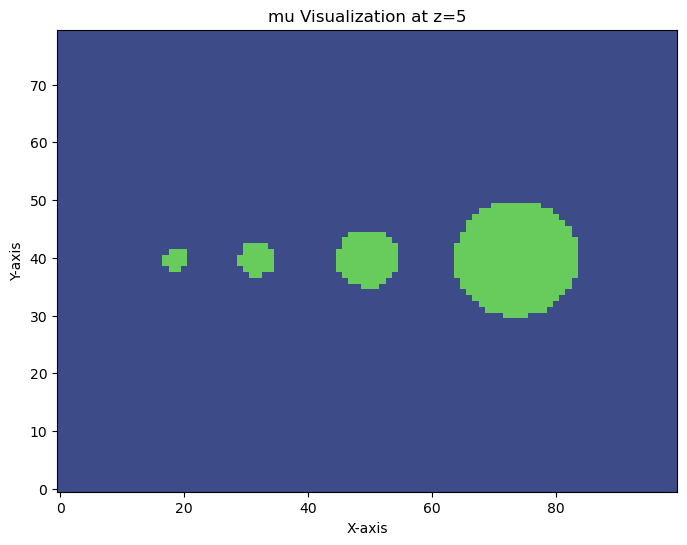

Image saved to ../Results/images/AHI_preds_70_0.0.png
Frequency : 70
mu pearson correlation: 0.5565370076201215
Region 1 CTE : 60.19474970274569 
Region 2 CTE : 82.96183489453543 
Region 3 CTE : 15.486823645823785 
Region 4 CTE : -0.4266450057212946
Mean CTE error: 60.445809190654096


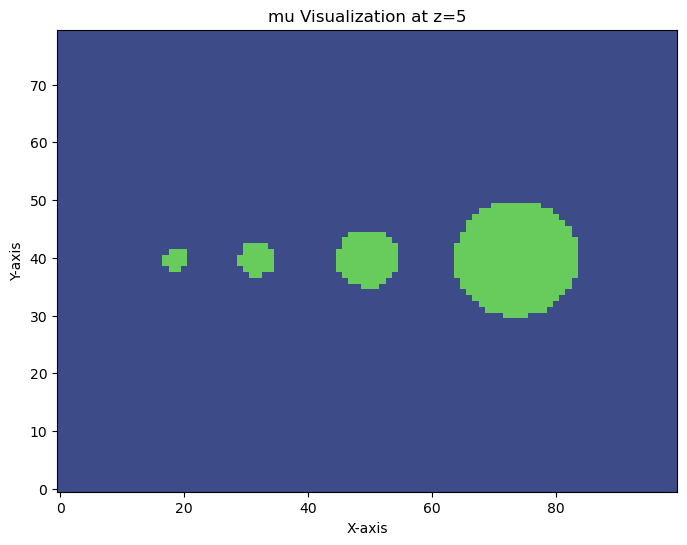

Image saved to ../Results/images/AHI_preds_80_0.0.png
Frequency : 80
mu pearson correlation: 0.5830659074730454
Region 1 CTE : 69.94061737360899 
Region 2 CTE : 50.19002272143916 
Region 3 CTE : -8.935036000710825 
Region 4 CTE : -2.758586580207748
Mean CTE error: 72.8907456214676


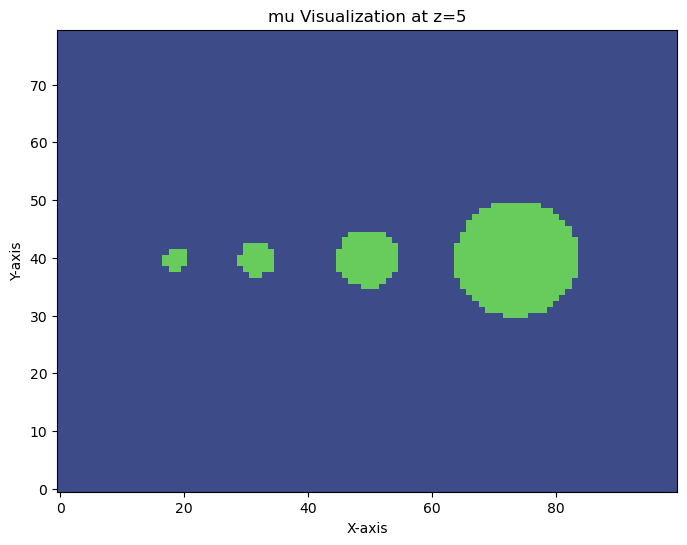

Image saved to ../Results/images/AHI_preds_90_0.0.png
Frequency : 90
mu pearson correlation: 0.4402176583462922
Region 1 CTE : 67.86924353090555 
Region 2 CTE : 14.446697002801967 
Region 3 CTE : 6.129262073092826 
Region 4 CTE : -5.936576271064041
Mean CTE error: 79.37284341606592


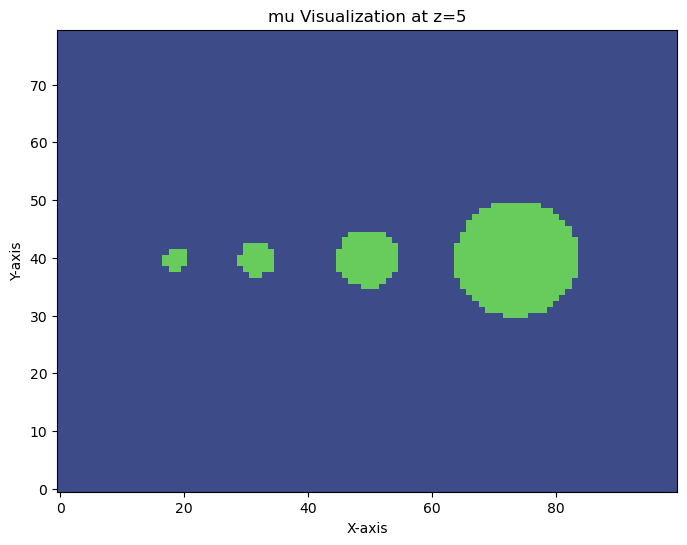

Image saved to ../Results/images/AHI_preds_100_0.0.png
Frequency : 100
mu pearson correlation: 0.46234792597672725
Region 1 CTE : 69.5888274472479 
Region 2 CTE : 112.79905301456519 
Region 3 CTE : 11.059963030231582 
Region 4 CTE : -3.9694149965174153
Mean CTE error: 59.02991938340078


In [7]:
for k, v in fem_box_dict.items():
    f = k
    mu_pred = v['example']['direct'].real.values
    mu = v['mu'].real
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'AHI_preds_{}_0.0.png'.format(f))
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### FEM-Helmholtz

In [8]:
hetero=False
for k, v in fem_box_dict.items():
    example = v['example']
    Baseline.mre_pinn.baseline.eval_fem_baseline(
        example,
        k,
        u_elem_type='CG-3',
        mu_elem_type='DG-1',
        savgol_filter=False,
        hetero=hetero
        )

Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:22<00:00, 20.22s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:35<00:00, 15.57s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:35<00:00, 21.58s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:27<00:00, 14.71s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:27<00:00, 20.78s/it]
Evaluating FEM baseline
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████

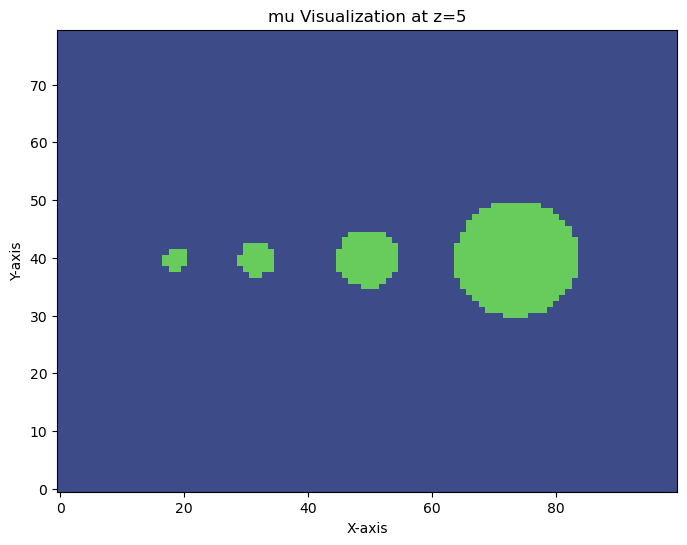

Image saved to ../Results/images/fem_hh_preds_50_0.0.png
Frequency : 50
mu pearson correlation: 0.38016247891470983
Region 1 CTE : 56.96979345992105 
Region 2 CTE : 2.3063198882721543 
Region 3 CTE : -9.462462879263336 
Region 4 CTE : 1.6977997390091526
Mean CTE error: 87.12213744801525


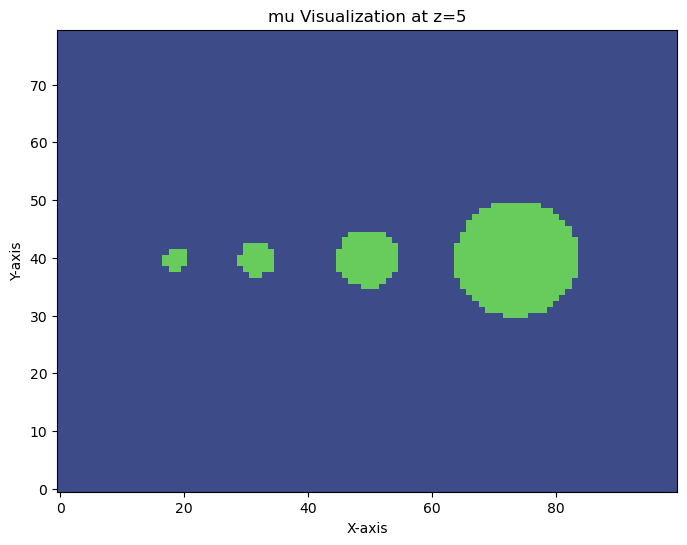

Image saved to ../Results/images/fem_hh_preds_60_0.0.png
Frequency : 60
mu pearson correlation: 0.4811761665041397
Region 1 CTE : 66.59532261162452 
Region 2 CTE : 30.010310244551576 
Region 3 CTE : -3.6683774889882574 
Region 4 CTE : 7.201349242120991
Mean CTE error: 74.96534884767279


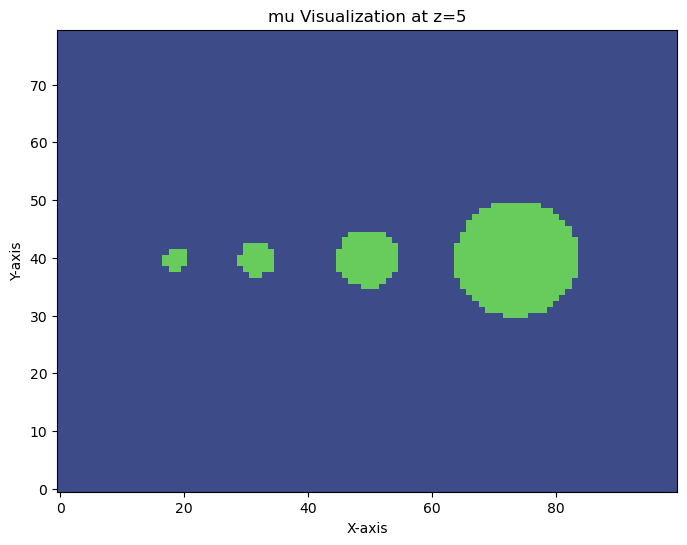

Image saved to ../Results/images/fem_hh_preds_70_0.0.png
Frequency : 70
mu pearson correlation: 0.5417019908690082
Region 1 CTE : 99.73576612295831 
Region 2 CTE : 20.542170923091984 
Region 3 CTE : 14.058374925188685 
Region 4 CTE : 52.12497886301934
Mean CTE error: 53.38467729143542


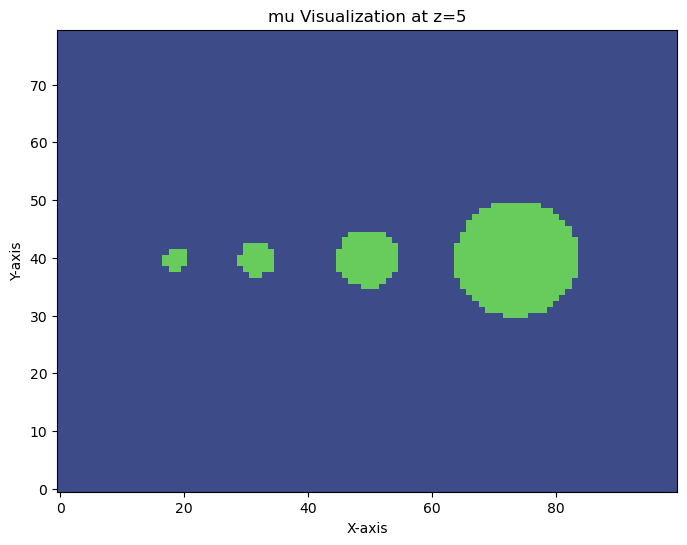

Image saved to ../Results/images/fem_hh_preds_80_0.0.png
Frequency : 80
mu pearson correlation: 0.5683608844717383
Region 1 CTE : 107.60198339556246 
Region 2 CTE : 40.980005087065585 
Region 3 CTE : 16.693837065782322 
Region 4 CTE : 33.98837774064163
Mean CTE error: 53.984940875518234


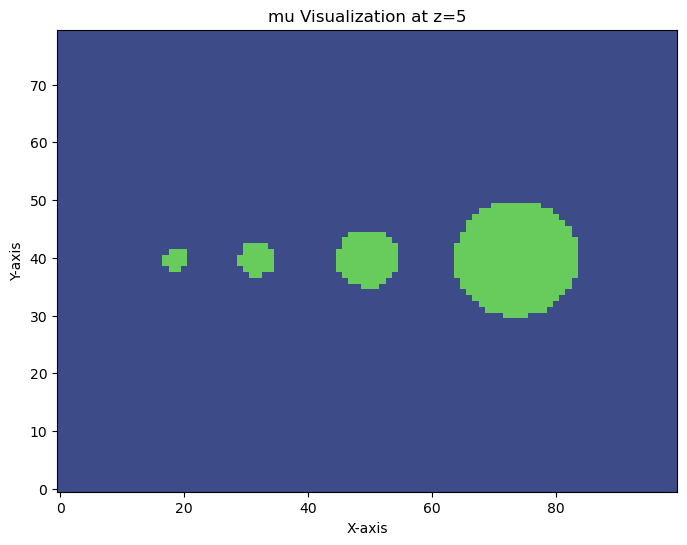

Image saved to ../Results/images/fem_hh_preds_90_0.0.png
Frequency : 90
mu pearson correlation: 0.5466767473537667
Region 1 CTE : 120.04917560550162 
Region 2 CTE : 29.02323593931876 
Region 3 CTE : 14.965573200700758 
Region 4 CTE : 58.09894782207654
Mean CTE error: 54.490354660851395


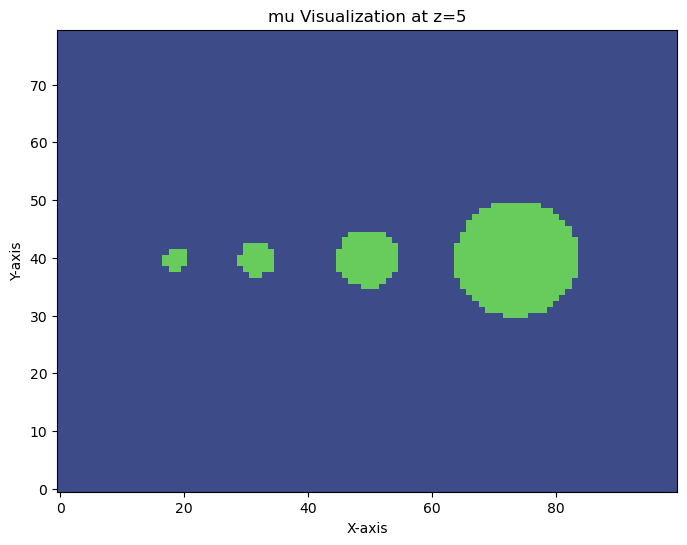

Image saved to ../Results/images/fem_hh_preds_100_0.0.png
Frequency : 100
mu pearson correlation: 0.6273855757768105
Region 1 CTE : 160.63828001770227 
Region 2 CTE : 75.47898236062575 
Region 3 CTE : 17.076274457849784 
Region 4 CTE : 40.910491741611125
Mean CTE error: 56.7931328644039


In [9]:
for k, v in fem_box_dict.items():
    f = k
    mu_pred = v['example']['fem'].real.values
    mu = v['mu'].real
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'fem_hh_preds_{}_0.0.png'.format(f))
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### FEM-Hetrogenous

In [10]:
hetero=True
for k, v in fem_box_dict.items():
    example = v['example']
    Baseline.mre_pinn.baseline.eval_fem_baseline(
        example,
        k,
        u_elem_type='CG-3',
        mu_elem_type='DG-1',
        savgol_filter=False,
        hetero=hetero
        )

Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [04:26<00:00, 26.65s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:23<00:00, 20.34s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:17<00:00, 19.73s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [04:03<00:00, 24.37s/it]
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:38<00:00, 21.84s/it]
Evaluating FEM baseline
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████

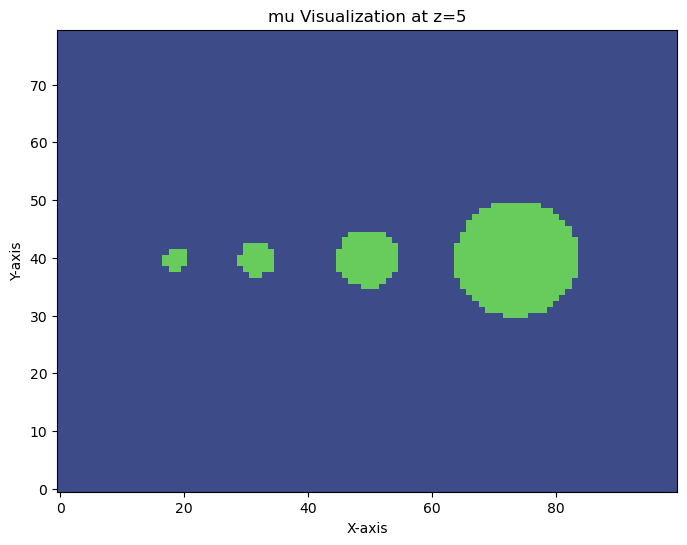

Image saved to ../Results/images/fem_het_preds_50_0.0.png
Frequency : 50
mu pearson correlation: 0.32257113293097955
Region 1 CTE : 55.01775643879194 
Region 2 CTE : 10.519964133170996 
Region 3 CTE : -1.3999626147565323 
Region 4 CTE : 11.066477336173381
Mean CTE error: 81.19894117665505


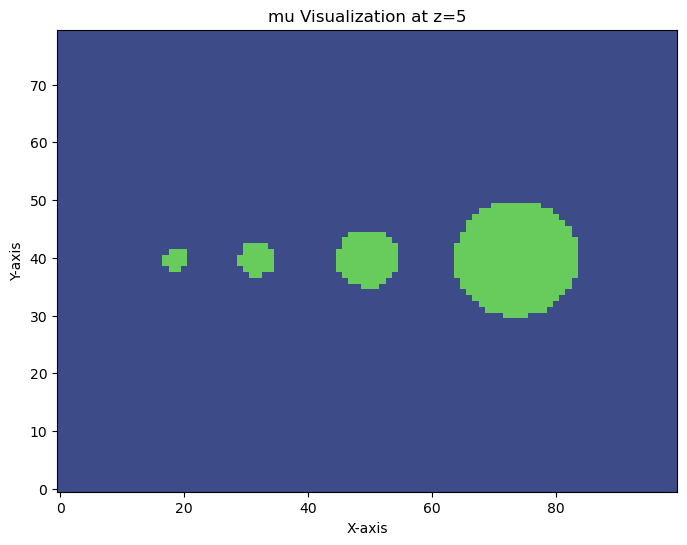

Image saved to ../Results/images/fem_het_preds_60_0.0.png
Frequency : 60
mu pearson correlation: 0.3732296763188404
Region 1 CTE : 50.60271572426949 
Region 2 CTE : 9.235098092352278 
Region 3 CTE : -1.1837393102162812 
Region 4 CTE : 27.615264138843298
Mean CTE error: 78.43266533868781


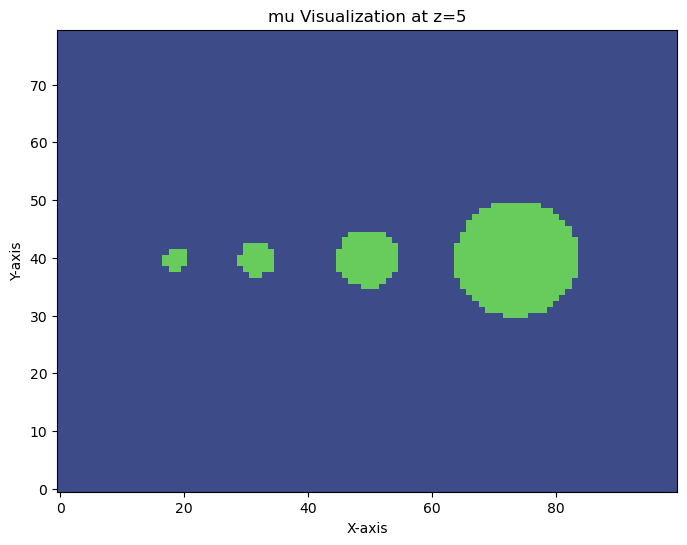

Image saved to ../Results/images/fem_het_preds_70_0.0.png
Frequency : 70
mu pearson correlation: 0.37748300019411263
Region 1 CTE : 70.7743678788653 
Region 2 CTE : 14.182324731885181 
Region 3 CTE : 25.87900946163584 
Region 4 CTE : 115.494118871699
Mean CTE error: 51.164604199828176


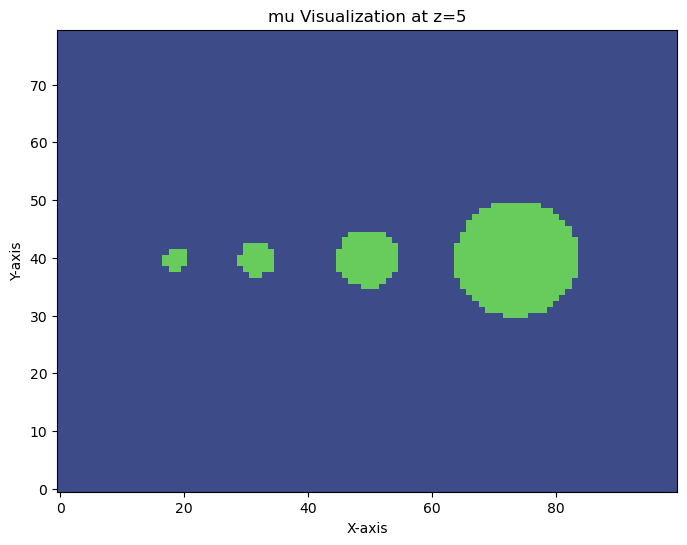

Image saved to ../Results/images/fem_het_preds_80_0.0.png
Frequency : 80
mu pearson correlation: 0.4588876541651572
Region 1 CTE : 89.56411545213312 
Region 2 CTE : 50.19086112040585 
Region 3 CTE : 30.9728151885655 
Region 4 CTE : 66.882277008241
Mean CTE error: 40.59748280766363


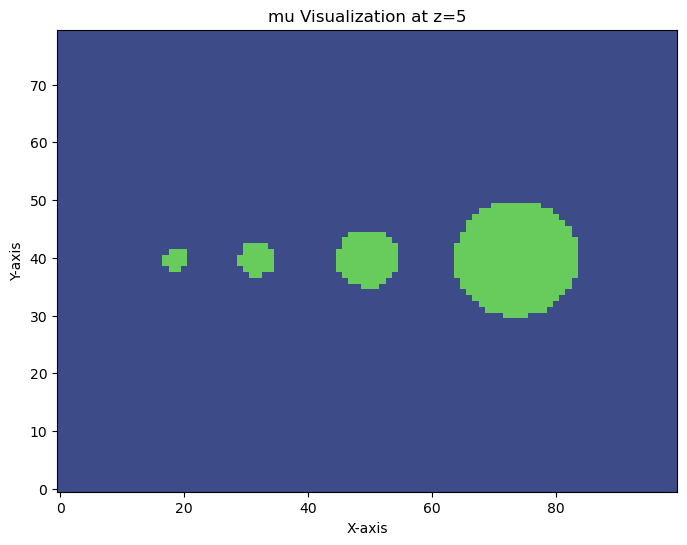

Image saved to ../Results/images/fem_het_preds_90_0.0.png
Frequency : 90
mu pearson correlation: 0.3608532969431152
Region 1 CTE : 78.2236433688026 
Region 2 CTE : -8.045090817712408 
Region 3 CTE : 7.771095248011255 
Region 4 CTE : 61.62998004081551
Mean CTE error: 65.10509304002076


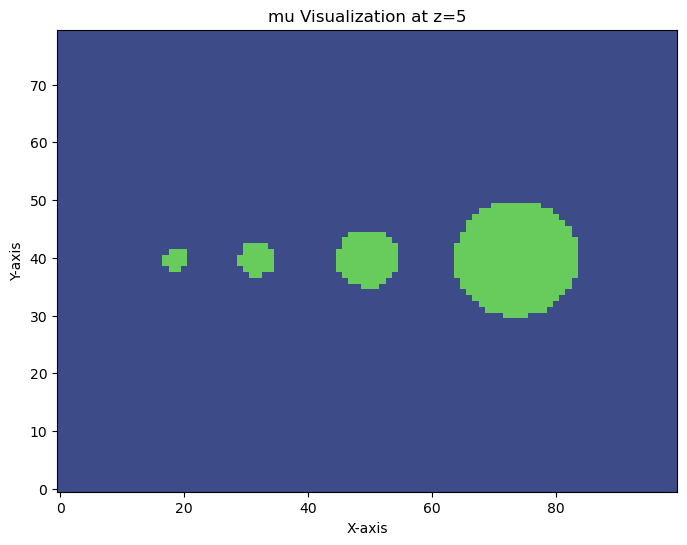

Image saved to ../Results/images/fem_het_preds_100_0.0.png
Frequency : 100
mu pearson correlation: 0.5291407124531136
Region 1 CTE : 148.73330761104674 
Region 2 CTE : 58.422392503564744 
Region 3 CTE : 39.82513328198062 
Region 4 CTE : 74.96534565625072
Mean CTE error: 43.88010904231267


In [11]:
for k, v in fem_box_dict.items():
    f = k
    mu_pred = v['example']['fem'].real.values
    mu = v['mu'].real
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'fem_het_preds_{}_0.0.png'.format(f))
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

## Noise Experiment results

In [17]:
noise_ratios = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
f = 90

### MREHyper


---------------    noise ratio : 1e-05   -----------------



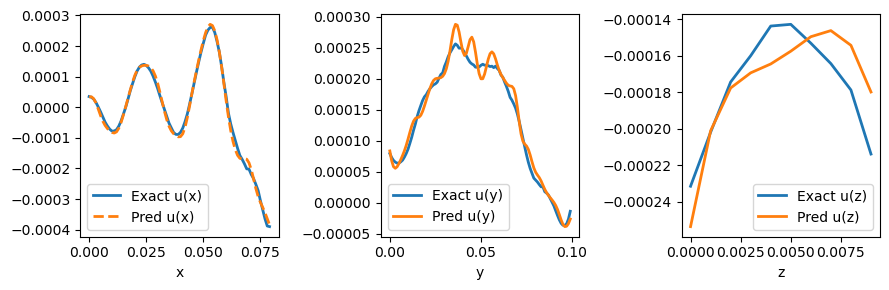

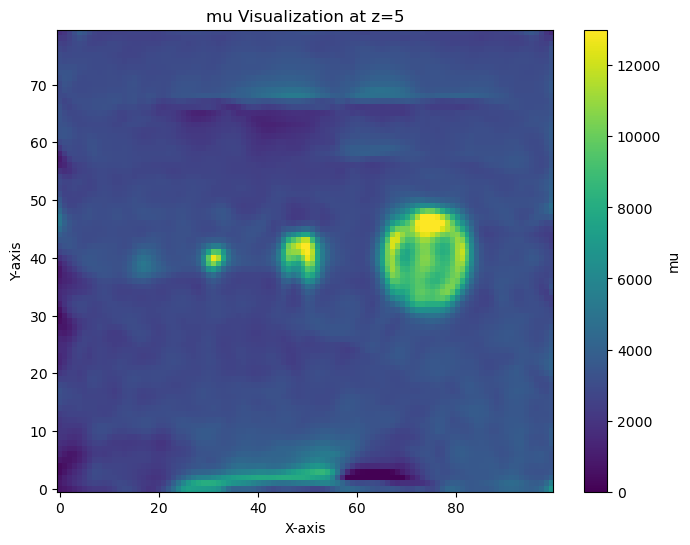

Noise ratio : 1e-05
Frequency : 90
u recon relative L2 error: 0.039608078517862716
mu pearson correlation: 0.8027306495516664
Region 1 CTE : 80.95920758928571 
Region 2 CTE : 65.85513392857143 
Region 3 CTE : 50.271759905133926 
Region 4 CTE : 18.88944266183036
Mean CTE error: 46.006113978794644

---------------    noise ratio : 0.0001   -----------------



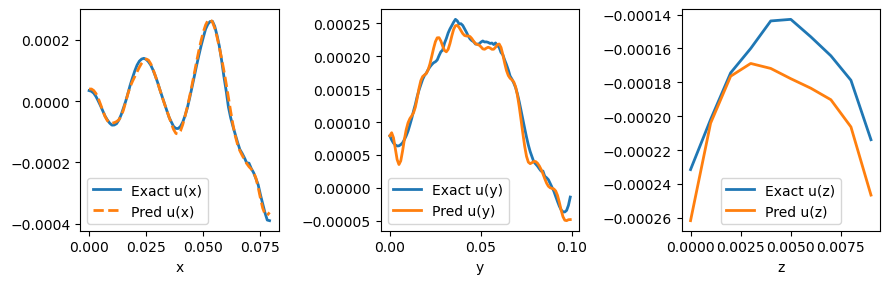

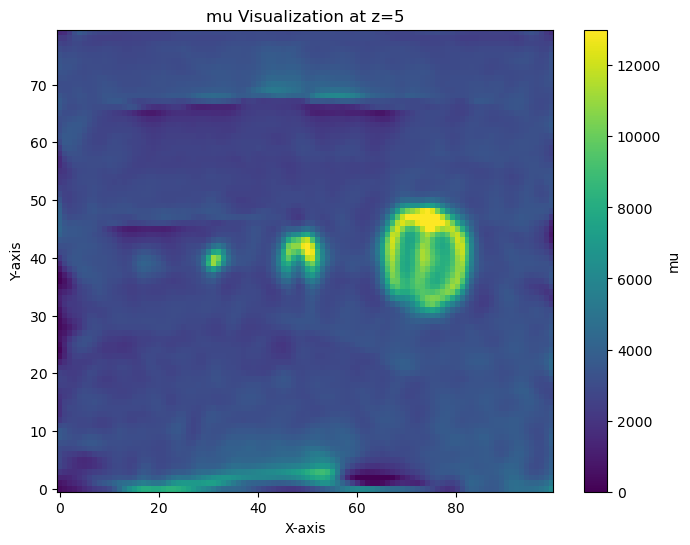

Noise ratio : 0.0001
Frequency : 90
u recon relative L2 error: 0.0403558495844316
mu pearson correlation: 0.7921025376243666
Region 1 CTE : 83.08768833705356 
Region 2 CTE : 63.63001534598214 
Region 3 CTE : 43.356577845982144 
Region 4 CTE : 8.167825753348215
Mean CTE error: 50.43947317940849

---------------    noise ratio : 0.001   -----------------



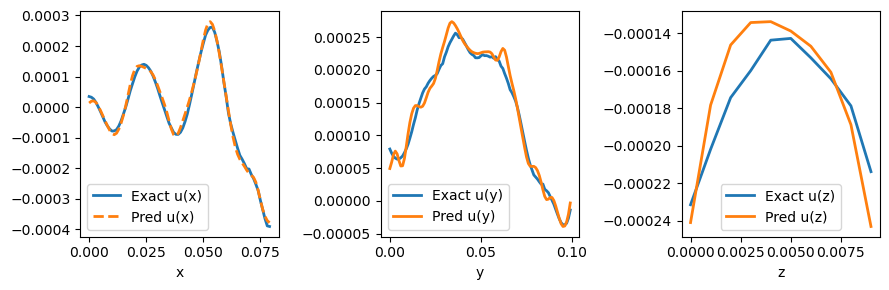

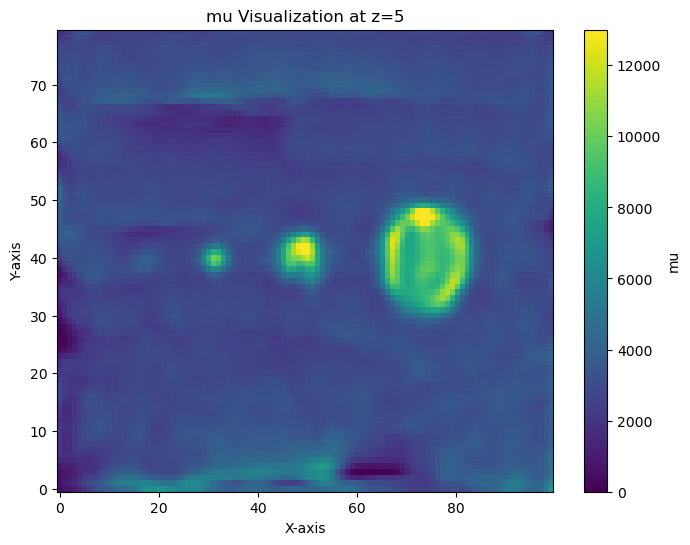

Noise ratio : 0.001
Frequency : 90
u recon relative L2 error: 0.05536099053076918
mu pearson correlation: 0.8133708304690673
Region 1 CTE : 79.61268833705357 
Region 2 CTE : 66.24387555803571 
Region 3 CTE : 43.22056361607143 
Region 4 CTE : 7.034922572544643
Mean CTE error: 50.97198747907366

---------------    noise ratio : 0.01   -----------------



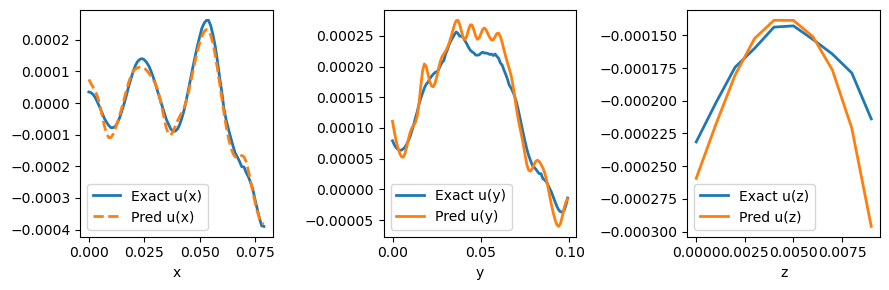

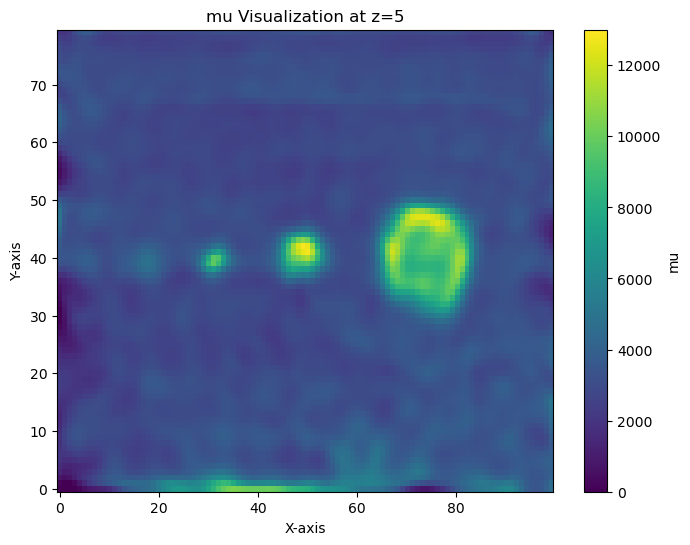

Noise ratio : 0.01
Frequency : 90
u recon relative L2 error: 0.0920001072612678
mu pearson correlation: 0.788428569291596
Region 1 CTE : 77.69715401785714 
Region 2 CTE : 60.43809988839286 
Region 3 CTE : 42.555025809151786 
Region 4 CTE : 17.786226981026786
Mean CTE error: 50.38087332589285

---------------    noise ratio : 0.1   -----------------



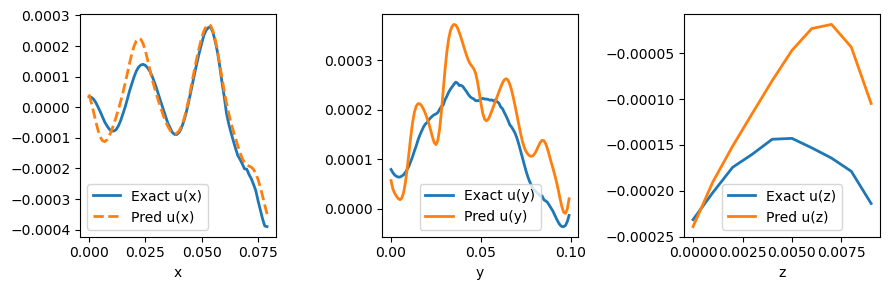

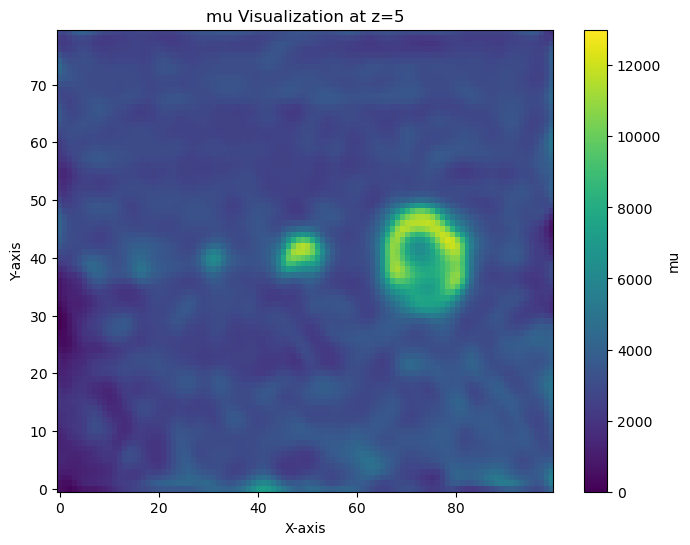

Noise ratio : 0.1
Frequency : 90
u recon relative L2 error: 0.1942084106882646
mu pearson correlation: 0.8002297352930341
Region 1 CTE : 74.15191127232143 
Region 2 CTE : 55.090359933035714 
Region 3 CTE : 27.19291294642857 
Region 4 CTE : 13.882571847098212
Mean CTE error: 57.420561000279015


In [18]:
for noise in noise_ratios:
    data_file = fem_box_results_path+'MREHyper_preds_{}_{}.pkl'.format(f, noise)
    print('\n---------------    noise ratio : {}   -----------------\n'.format(noise))
    with open(data_file, 'rb') as file:
        data = pickle.load(file)
        u_pred, u, mu_pred, mu = data
        z_fixed = 5
        #visualize_mu_slice(u[...,0], fixed_axis='z', fixed_index=z_fixed, cmap=bright_cmap, vmin=-0.002, vmax=0.002, log_scale=False, save_path=fem_box_img_path+'wave_{}_{}.png'.format(f, noise))
        u = fem_box_dict[f]['u']
        u_compare_visualization(u_pred.reshape(*coords_shape, 3).detach().cpu().numpy(), u, x, (30, 90, 5))
        z_fixed = 5
        mu_pred = mu_pred.reshape(*coords_shape).real.detach().cpu().numpy()
        #visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
        visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'MREHyper_preds_{}_{}.png'.format(f, noise))
        rel_l2_loss = relative_l2_loss(u_pred.real.detach().cpu().numpy(), u.reshape(-1,3))
        ex = fem_box_dict[f]['example']
        region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
        print('Noise ratio : {}'.format(noise))
        print('Frequency : {}'.format(f))
        print('u recon relative L2 error: {}'.format(rel_l2_loss))
        print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
        print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
        print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### MRE-PINN


---------------    noise ratio : 1e-05   -----------------



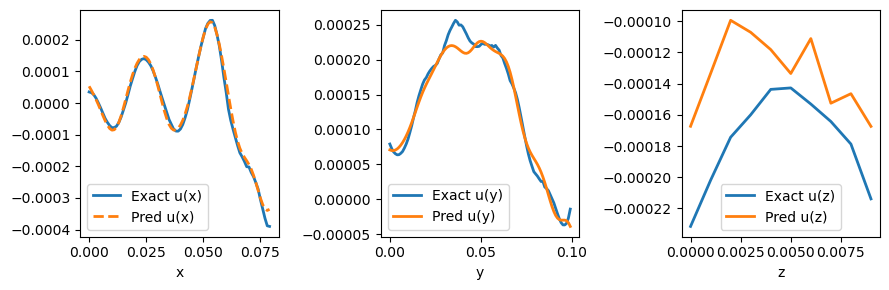

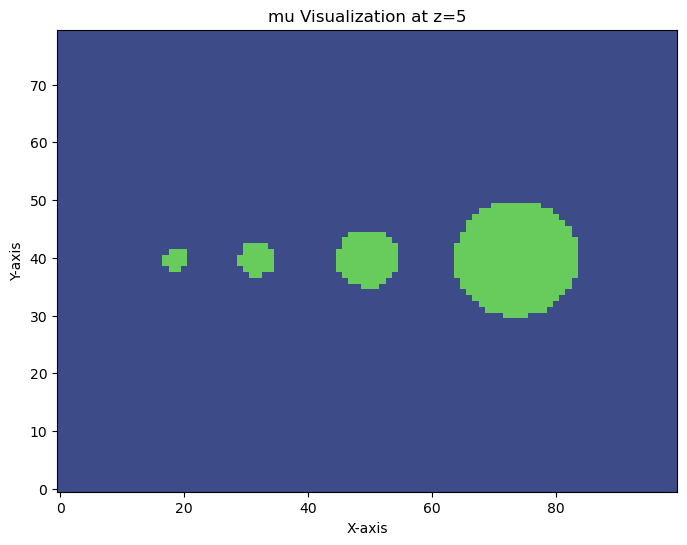

Image saved to ../Results/images/mrepinn_preds_90_1e-05.png
Noise ratio : 1e-05
Frequency : 90
u recon relative L2 error: 0.050897024496996825
mu pearson correlation: 0.7260181761815837
Region 1 CTE : 64.22860304807894 
Region 2 CTE : 40.3958143041903 
Region 3 CTE : 45.52620354896129 
Region 4 CTE : 22.665202788182114
Mean CTE error: 56.79604407764684

---------------    noise ratio : 0.0001   -----------------



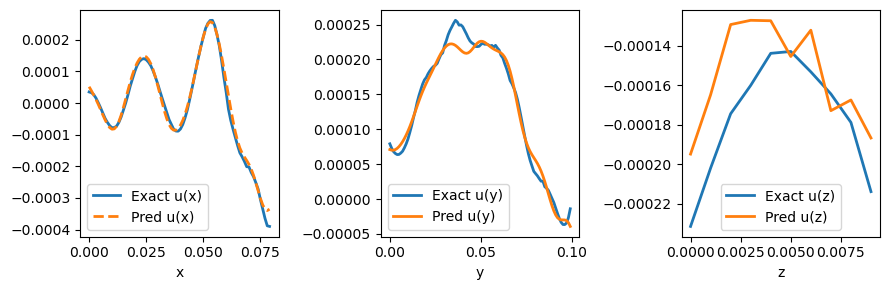

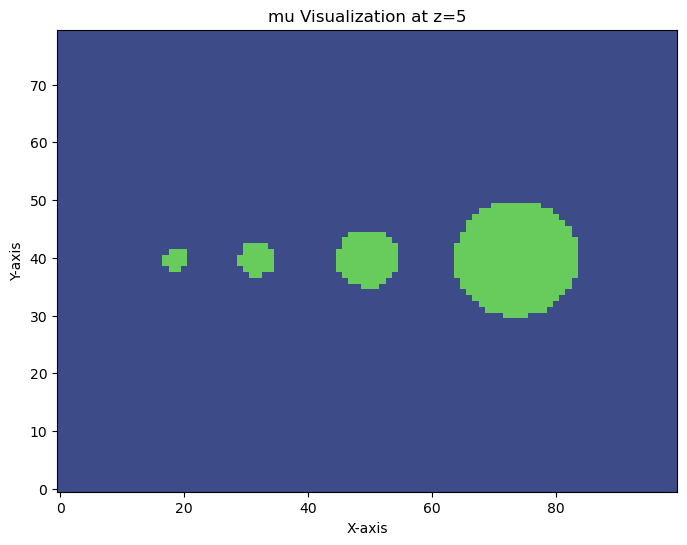

Image saved to ../Results/images/mrepinn_preds_90_0.0001.png
Noise ratio : 0.0001
Frequency : 90
u recon relative L2 error: 0.05228032873057428
mu pearson correlation: 0.7259212237087451
Region 1 CTE : 64.14759711072226 
Region 2 CTE : 40.540240541115416 
Region 3 CTE : 46.3591246812415 
Region 4 CTE : 24.575622177562366
Mean CTE error: 56.09435387233962

---------------    noise ratio : 0.001   -----------------



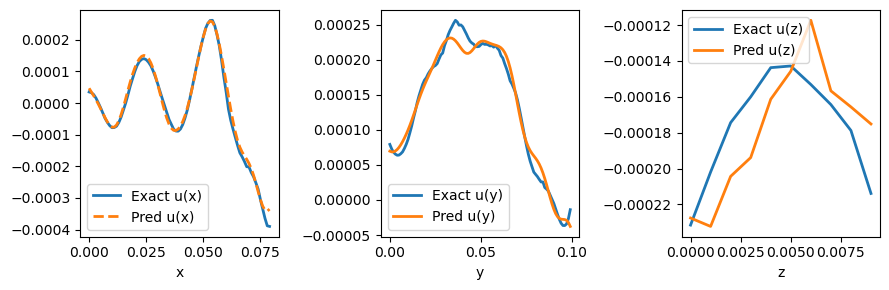

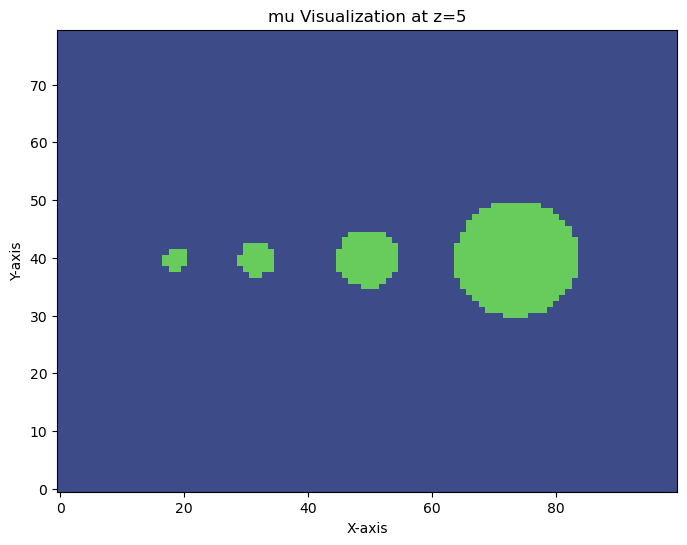

Image saved to ../Results/images/mrepinn_preds_90_0.001.png
Noise ratio : 0.001
Frequency : 90
u recon relative L2 error: 0.05737401418925698
mu pearson correlation: 0.7296082117673061
Region 1 CTE : 64.09352188298108 
Region 2 CTE : 40.978812531331194 
Region 3 CTE : 44.446154080875054 
Region 4 CTE : 21.795325146836753
Mean CTE error: 57.17154658949398

---------------    noise ratio : 0.01   -----------------



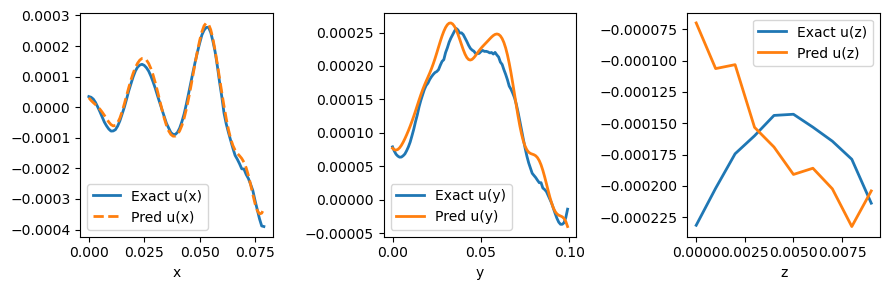

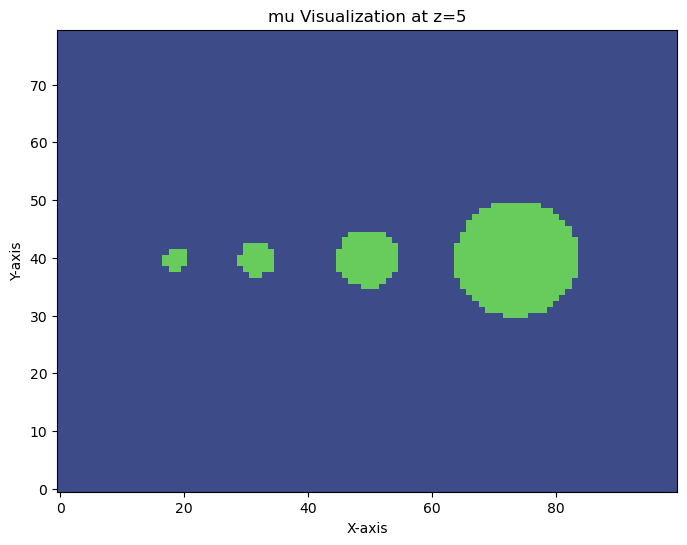

Image saved to ../Results/images/mrepinn_preds_90_0.01.png
Noise ratio : 0.01
Frequency : 90
u recon relative L2 error: 0.08894542326898383
mu pearson correlation: 0.7267168995533342
Region 1 CTE : 63.49352138956172 
Region 2 CTE : 40.02094212569612 
Region 3 CTE : 44.59755497611094 
Region 4 CTE : 23.463529491523637
Mean CTE error: 57.10611300427689

---------------    noise ratio : 0.1   -----------------



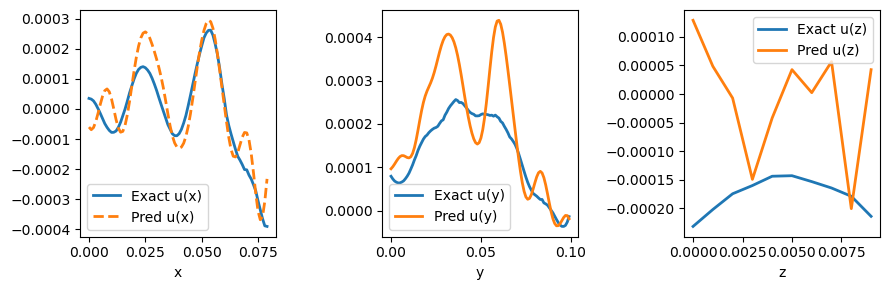

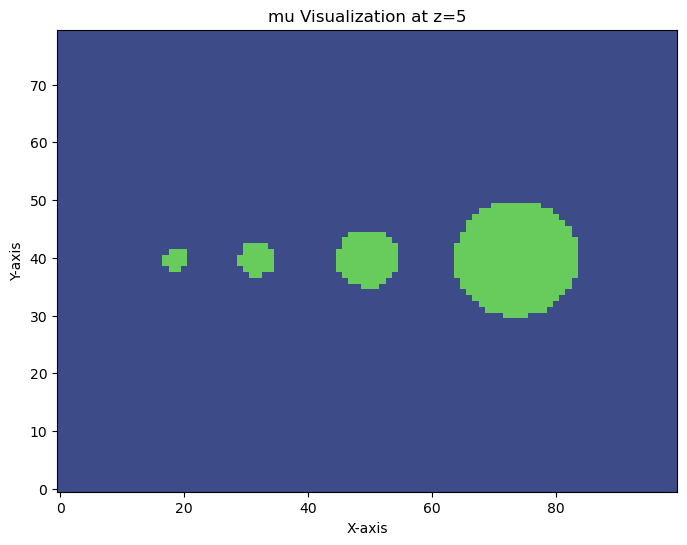

Image saved to ../Results/images/mrepinn_preds_90_0.1.png
Noise ratio : 0.1
Frequency : 90
u recon relative L2 error: 0.23345208502980727
mu pearson correlation: 0.726645201848856
Region 1 CTE : 59.634854443990015 
Region 2 CTE : 36.66544042995829 
Region 3 CTE : 41.80483590135883 
Region 4 CTE : 24.322219941104837
Mean CTE error: 59.393162320897005


In [37]:
for noise in noise_ratios:
    data_file = fem_box_results_path+'mrepinn_preds_{}_{}.pkl'.format(f, noise)
    print('\n---------------    noise ratio : {}   -----------------\n'.format(noise))
    with open(data_file, 'rb') as file:
        data = pickle.load(file)
        u_pred, _, mu_pred, mu = data
        u = fem_box_dict[f]['u']
        u_compare_visualization(u_pred.reshape(*coords_shape, 3).detach().cpu().numpy(), u, x, (30, 90, 5))
        z_fixed = 5
        mu_pred = mu_pred.reshape(*coords_shape).real.detach().cpu().numpy()
        visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
        visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'mrepinn_preds_{}_{}.png'.format(f, noise)
)
        rel_l2_loss = relative_l2_loss(u_pred.real.detach().cpu().numpy(), u.reshape(-1,3))
        ex = fem_box_dict[f]['example']
        region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
        print('Noise ratio : {}'.format(noise))
        print('Frequency : {}'.format(f))
        print('u recon relative L2 error: {}'.format(rel_l2_loss))
        print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
        print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
        print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))

### AHI


---------------    noise ratio : 1e-05   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating direct baseline


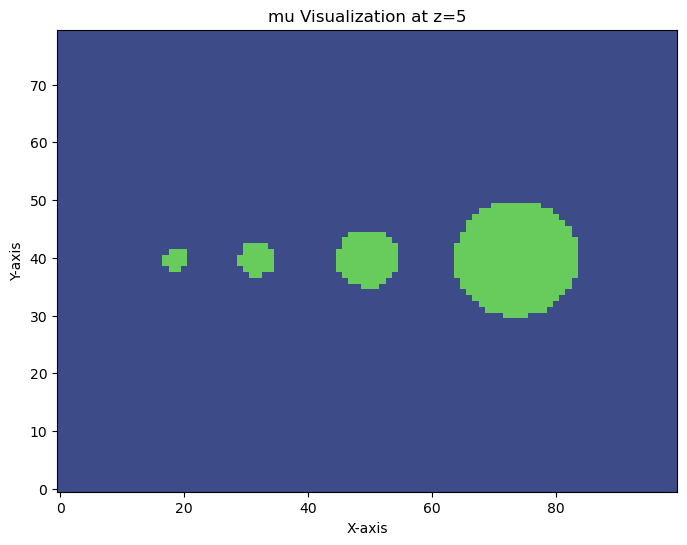

Image saved to ../Results/images/AHI_preds_90_1e-05.png
Noise ratio : 1e-05
Frequency : 90
mu pearson correlation: 0.4593169421820258
Region 1 CTE : 57.8689611965976 
Region 2 CTE : 7.75042248974887 
Region 3 CTE : 7.310358694189524 
Region 4 CTE : -3.7905568667229614
Mean CTE error: 82.71520362154675

---------------    noise ratio : 0.0001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating direct baseline


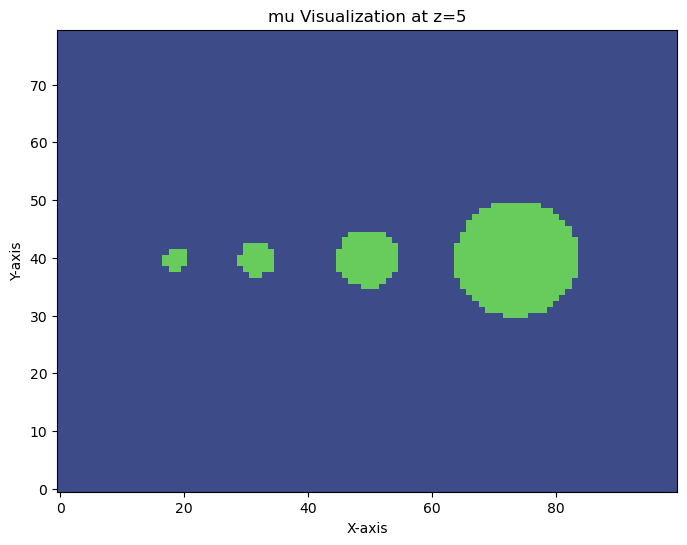

Image saved to ../Results/images/AHI_preds_90_0.0001.png
Noise ratio : 0.0001
Frequency : 90
mu pearson correlation: 0.3782473409127783
Region 1 CTE : 38.97187500470869 
Region 2 CTE : -2.958605250303916 
Region 3 CTE : 7.618695700135063 
Region 4 CTE : -0.883467364741955
Mean CTE error: 89.31287547755053

---------------    noise ratio : 0.001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating direct baseline


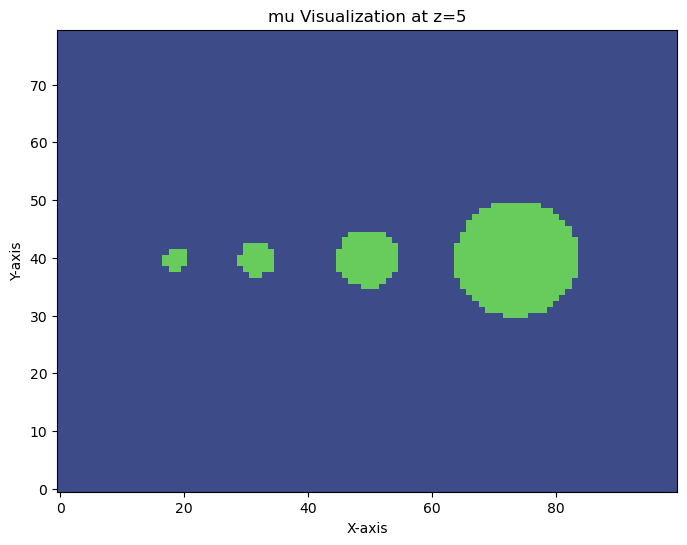

Image saved to ../Results/images/AHI_preds_90_0.001.png
Noise ratio : 0.001
Frequency : 90
mu pearson correlation: 0.0772823080879235
Region 1 CTE : 5.964244477714413 
Region 2 CTE : -14.807518378838827 
Region 3 CTE : 4.544896824213115 
Region 4 CTE : 1.6123890996865742
Mean CTE error: 100.67149699430617

---------------    noise ratio : 0.01   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating direct baseline


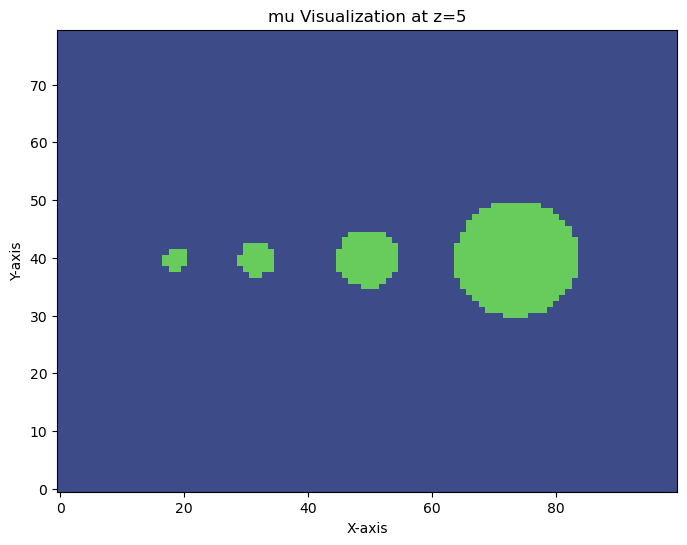

Image saved to ../Results/images/AHI_preds_90_0.01.png
Noise ratio : 0.01
Frequency : 90
mu pearson correlation: -0.07704411190612004
Region 1 CTE : -9.027393022206628 
Region 2 CTE : -9.64530029532797 
Region 3 CTE : -0.5391678920207305 
Region 4 CTE : 0.5937412446693575
Mean CTE error: 104.6545299912215

---------------    noise ratio : 0.1   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating direct baseline


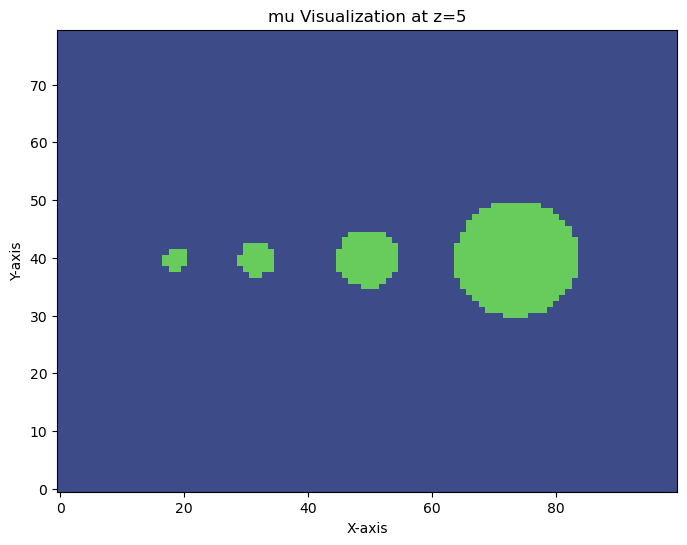

Image saved to ../Results/images/AHI_preds_90_0.1.png
Noise ratio : 0.1
Frequency : 90
mu pearson correlation: -0.07871398762758015
Region 1 CTE : -3.5329268275221657 
Region 2 CTE : -1.9746166681160977 
Region 3 CTE : 0.3851673197101994 
Region 4 CTE : -0.7198041655189441
Mean CTE error: 101.46054508536174


In [39]:
for noise in noise_ratios:
    print('\n---------------    noise ratio : {}   -----------------\n'.format(noise))
    example = MREExample.load_xarrays(dataroot, f)
    example.add_gaussian_noise(noise)
    Baseline.mre_pinn.baseline.eval_ahi_baseline(example, frequency=f, despeckle=True)
    mu_pred = example['direct'].real.values
    mu = fem_box_dict[f]['mu']
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'AHI_preds_{}_{}.png'.format(f, noise))
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Noise ratio : {}'.format(noise))
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))
    

### FEM-Helmholtz


---------------    noise ratio : 1e-05   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:23<00:00,  8.32s/it]


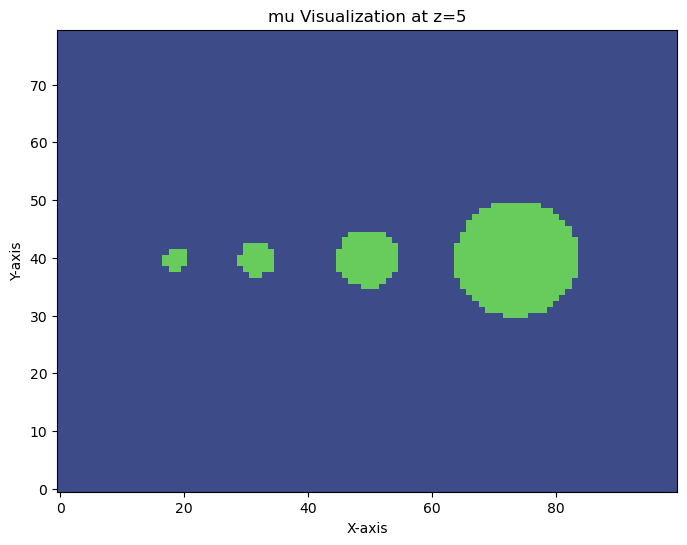

Image saved to ../Results/images/fem_hh_preds_90_1e-05.png
Noise ratio : 1e-05
Frequency : 90
mu pearson correlation: -0.04896895967784719
Region 1 CTE : -1.6405611190425784 
Region 2 CTE : -12.767650965887384 
Region 3 CTE : -6.7826450137971115 
Region 4 CTE : 9.849273365751118
Mean CTE error: 102.83539593324399

---------------    noise ratio : 0.0001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:50<00:00,  5.08s/it]


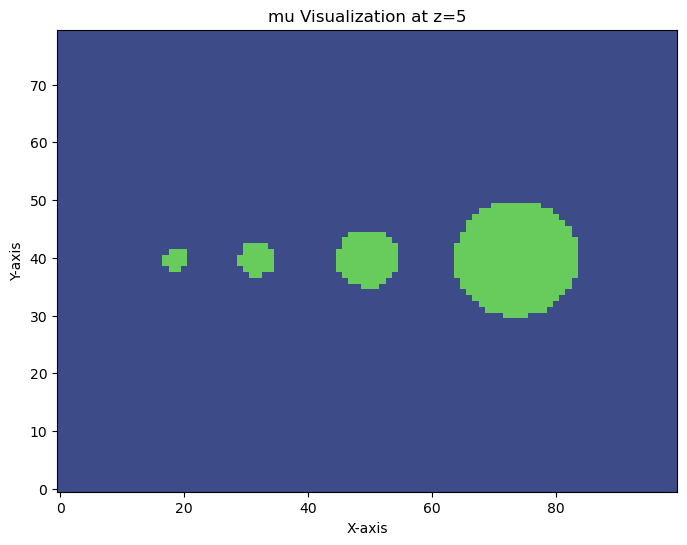

Image saved to ../Results/images/fem_hh_preds_90_0.0001.png
Noise ratio : 0.0001
Frequency : 90
mu pearson correlation: -0.09149459731535423
Region 1 CTE : -1.9980447797126095 
Region 2 CTE : -4.929349678068154 
Region 3 CTE : -3.872105025125254 
Region 4 CTE : -0.6337627930459055
Mean CTE error: 102.85831556898798

---------------    noise ratio : 0.001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:39<00:00,  3.98s/it]


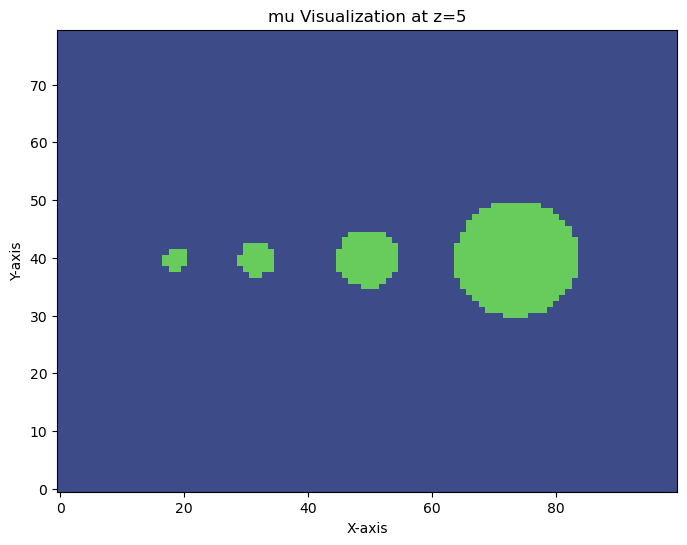

Image saved to ../Results/images/fem_hh_preds_90_0.001.png
Noise ratio : 0.001
Frequency : 90
mu pearson correlation: -0.03998838761365575
Region 1 CTE : -0.16203720658965243 
Region 2 CTE : -0.6488873483066557 
Region 3 CTE : -0.3554277401357774 
Region 4 CTE : -0.17800323911882612
Mean CTE error: 100.33608888353773

---------------    noise ratio : 0.01   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:38<00:00,  3.80s/it]


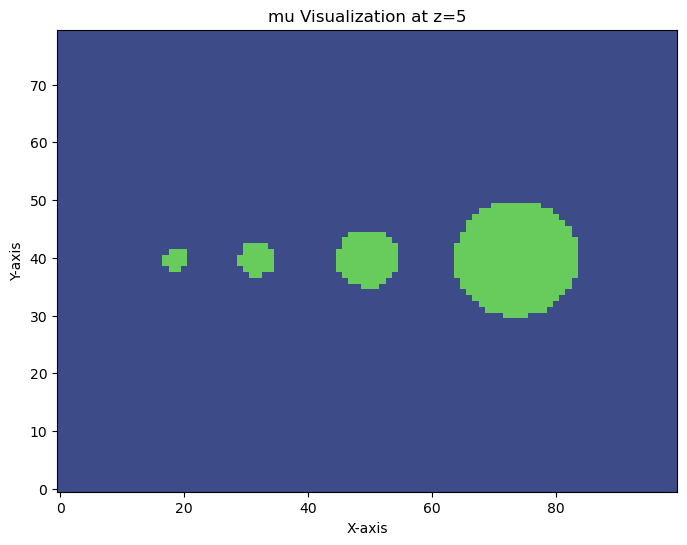

Image saved to ../Results/images/fem_hh_preds_90_0.01.png
Noise ratio : 0.01
Frequency : 90
mu pearson correlation: -0.012697040361214138
Region 1 CTE : -0.014316773898922212 
Region 2 CTE : -0.09202750602652157 
Region 3 CTE : -0.09100446773748844 
Region 4 CTE : -0.029311454786713396
Mean CTE error: 100.05666505061241

---------------    noise ratio : 0.1   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:48<00:00,  4.83s/it]


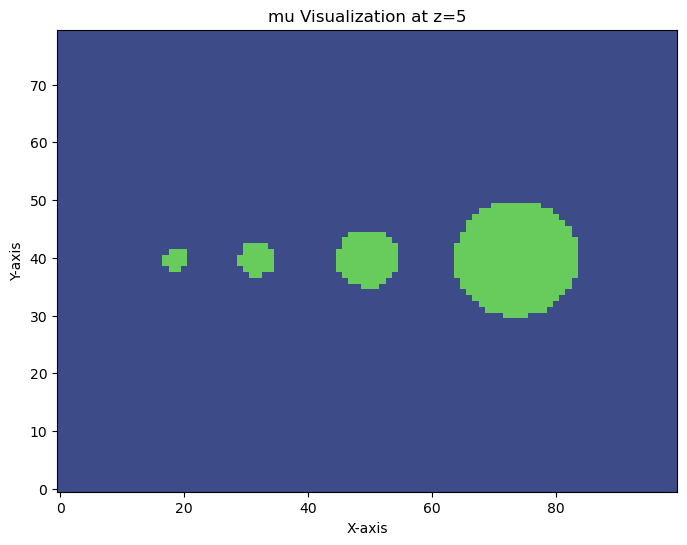

Image saved to ../Results/images/fem_hh_preds_90_0.1.png
Noise ratio : 0.1
Frequency : 90
mu pearson correlation: -0.0024958464727503718
Region 1 CTE : -0.0016628368917236814 
Region 2 CTE : -0.03233835003623581 
Region 3 CTE : -0.05657132018112086 
Region 4 CTE : 0.11676998499177266
Mean CTE error: 99.99345063052932


In [40]:
hetero=False
for noise in noise_ratios:
    print('\n---------------    noise ratio : {}   -----------------\n'.format(noise))
    example = MREExample.load_xarrays(dataroot, f)
    example.add_gaussian_noise(noise)
    Baseline.mre_pinn.baseline.eval_fem_baseline(example, f, u_elem_type='CG-3',mu_elem_type='DG-1',savgol_filter=False,hetero=hetero)
    mu_pred = example['fem'].real.values
    mu = fem_box_dict[f]['mu']
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'fem_hh_preds_{}_{}.png'.format(f, noise)
)
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Noise ratio : {}'.format(noise))
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))
    

### FEM-Heterogenous


---------------    noise ratio : 1e-05   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:25<00:00,  8.52s/it]


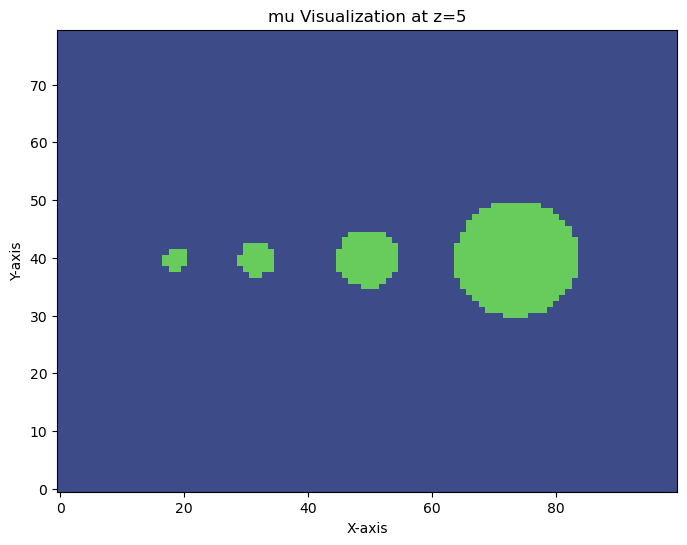

Image saved to ../Results/images/fem_het_preds_90_1e-05.png
Noise ratio : 1e-05
Frequency : 90
mu pearson correlation: -0.025892537181862327
Region 1 CTE : -0.635916217738957 
Region 2 CTE : -16.958886182885518 
Region 3 CTE : -4.0910881091272975 
Region 4 CTE : 8.4661686007579
Mean CTE error: 103.30493047724846

---------------    noise ratio : 0.0001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:52<00:00,  5.30s/it]


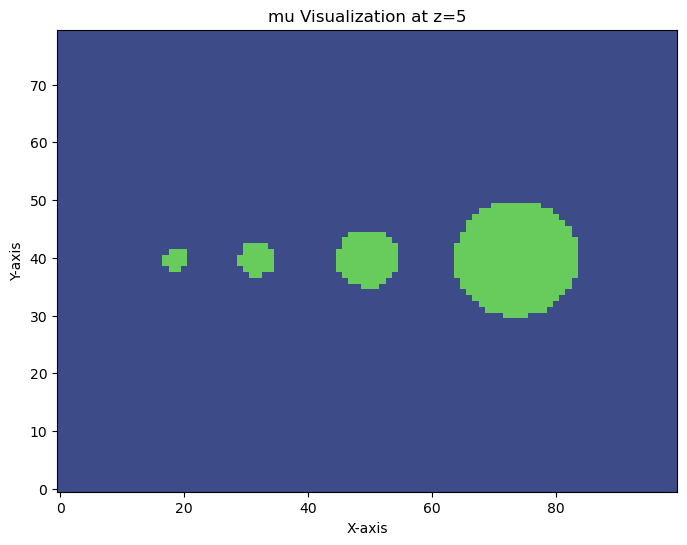

Image saved to ../Results/images/fem_het_preds_90_0.0001.png
Noise ratio : 0.0001
Frequency : 90
mu pearson correlation: -0.02287680919857618
Region 1 CTE : 0.4033056480628675 
Region 2 CTE : -5.545790099752825 
Region 3 CTE : -2.492212619678585 
Region 4 CTE : 0.4756367198799524
Mean CTE error: 101.78976508787214

---------------    noise ratio : 0.001   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:43<00:00,  4.36s/it]


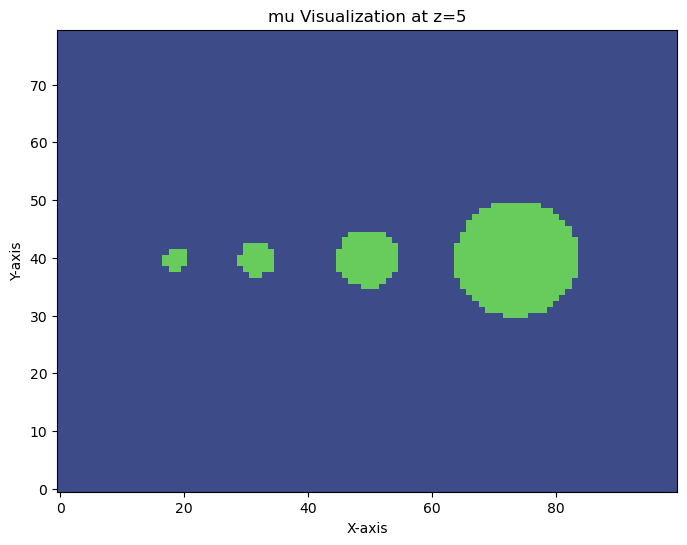

Image saved to ../Results/images/fem_het_preds_90_0.001.png
Noise ratio : 0.001
Frequency : 90
mu pearson correlation: -0.02389313531275293
Region 1 CTE : 0.34261960542664066 
Region 2 CTE : -0.5004068837990882 
Region 3 CTE : -0.24713271744103135 
Region 4 CTE : 0.537787861779544
Mean CTE error: 99.96678303350848

---------------    noise ratio : 0.01   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.56s/it]


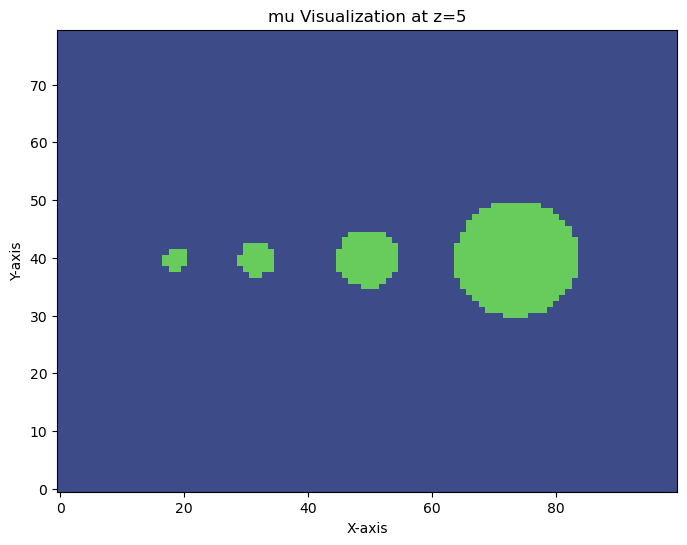

Image saved to ../Results/images/fem_het_preds_90_0.01.png
Noise ratio : 0.01
Frequency : 90
mu pearson correlation: -0.009965047521749317
Region 1 CTE : 0.07353004012147073 
Region 2 CTE : 0.010658916710316038 
Region 3 CTE : 0.1043866664642264 
Region 4 CTE : -0.10022269291528098
Mean CTE error: 99.97791176740482

---------------    noise ratio : 0.1   -----------------

Loading ../Data/BIOQIC/fem_box/90/wave.nc
Loading ../Data/BIOQIC/fem_box/90/mre.nc
Loading ../Data/BIOQIC/fem_box/90/mre_mask.nc
Evaluating FEM baseline
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:36<00:00,  3.69s/it]


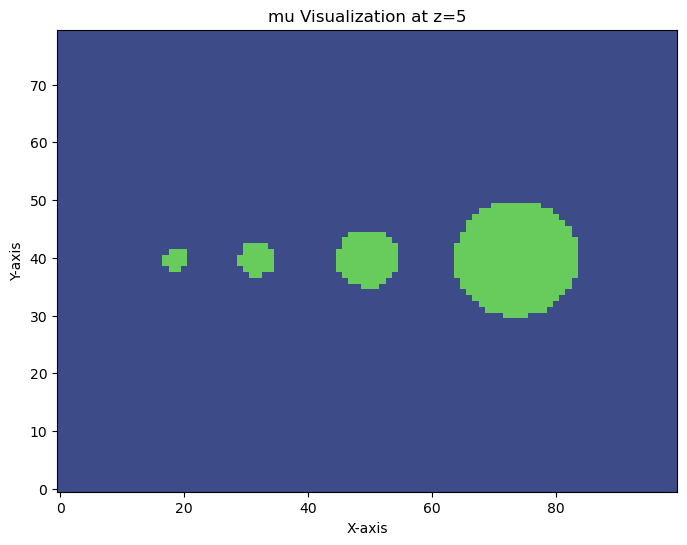

Image saved to ../Results/images/fem_het_preds_90_0.1.png
Noise ratio : 0.1
Frequency : 90
mu pearson correlation: -0.004936535428694278
Region 1 CTE : 0.012168622990465394 
Region 2 CTE : -0.08379879796242205 
Region 3 CTE : 0.011772223812085616 
Region 4 CTE : -0.1334663473534649
Mean CTE error: 100.04833107462834


In [41]:
hetero=True
for noise in noise_ratios:
    print('\n---------------    noise ratio : {}   -----------------\n'.format(noise))
    example = MREExample.load_xarrays(dataroot, f)
    example.add_gaussian_noise(noise)
    Baseline.mre_pinn.baseline.eval_fem_baseline(example, f, u_elem_type='CG-3',mu_elem_type='DG-1',savgol_filter=False,hetero=hetero)
    mu_pred = example['fem'].real.values
    mu = fem_box_dict[f]['mu']
    z_fixed = 5
    visualize_mu_slice(mu, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')
    visualize_mu_slice(mu_pred, fixed_axis='z', fixed_index=z_fixed, vmax=13000, vmin=0, cmap='viridis')#, save_path=fem_box_img_path+'fem_het_preds_{}_{}.png'.format(f, noise)

)
    ex = fem_box_dict[f]['example']
    region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE = compute_CTE(mu_pred, mu, ex.mre.spatial_region.values)
    print('Noise ratio : {}'.format(noise))
    print('Frequency : {}'.format(f))
    print('mu pearson correlation: {}'.format(compute_pearson(mu_pred, ex.mre).values))
    print('Region 1 CTE : {} \nRegion 2 CTE : {} \nRegion 3 CTE : {} \nRegion 4 CTE : {}'.format(region_1_CTE, region_2_CTE, region_3_CTE , region_4_CTE))
    print('Mean CTE error: {}'.format((np.abs(100-region_1_CTE) +np.abs(100-region_2_CTE) +np.abs(100-region_3_CTE) + np.abs(100-region_4_CTE))/4))
    